# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.


In [ ]:
# importar librerías

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [ ]:
# Cargar datasets

orders = pd.read_csv(
    "https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv"
)

catalog = pd.read_csv(
    "https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv"
)

marketing = pd.read_csv(
    "https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv"
)

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [ ]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [ ]:
catalog.head(7)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
5,Sneakers-Urban-42,Moda,17.21,Greene-Smith
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes


In [ ]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


#### Exploración inicial de los datos

Se analizaron tres datasets relacionados con pedidos, catálogo de productos e inversión en marketing.

**Dataset de pedidos (`orders`)**
- Contiene 25,100 registros y 12 columnas.
- Se identifican valores nulos en múltiples variables:
  - `pais` (300 valores nulos)
  - `dispositivo` (20 valores nulos)
  - `fuente_referencia` (30 valores nulos)
  - `nombre_producto` (30 valores nulos)
  - `categoria_producto` (80 valores nulos)
  - `cantidad` (50 valores nulos)
  - `precio_unitario` (50 valores nulos)
  - `monto_descuento` (50 valores nulos)

- La columna `fecha_hora_pedido` se encuentra como tipo `object` y deberá convertirse a formato fecha para facilitar análisis temporales.

**Dataset de catálogo (`catalog`)**
- Contiene 7 registros y 4 columnas.
- No presenta valores nulos.
- Los tipos de datos son consistentes con la naturaleza de las variables.

**Dataset de marketing (`marketing`)**
- Contiene 1,620 registros y 5 columnas.
- La columna `canal` presenta 101 valores nulos.
- La columna `fecha` se encuentra como tipo `object` y deberá convertirse a formato fecha para análisis temporales.

**Próximos pasos**
- Validar registros duplicados.
- Revisar categorías esperadas.
- Convertir variables de fecha al tipo adecuado.
- Analizar la naturaleza de los valores nulos antes de decidir si se imputan o eliminan.

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

In [ ]:
# tu código aquí
# Convertir columnas de fecha

orders["fecha_hora_pedido"] = pd.to_datetime(
    orders["fecha_hora_pedido"],
    errors="coerce"
)

marketing["fecha"] = pd.to_datetime(
    marketing["fecha"],
    errors="coerce"
)

# Verificar valores nulos generados por conversiones fallidas

print("Fechas inválidas orders:")
print(orders["fecha_hora_pedido"].isna().sum())

print("\nFechas inválidas marketing:")
print(marketing["fecha"].isna().sum())

Fechas inválidas orders:
0

Fechas inválidas marketing:
0


#### Conversión y validación de fechas

Se convirtieron las columnas `fecha_hora_pedido` y `fecha` al tipo de dato `datetime` para facilitar análisis temporales posteriores, como tendencias de pedidos, evolución de ingresos y comportamiento de campañas de marketing.

Posteriormente, se verificó si la conversión generaba valores nulos debido a formatos de fecha inválidos. No se detectaron errores de conversión en ninguno de los datasets, por lo que todas las fechas se consideran válidas y aptas para el análisis.

In [ ]:


# Revisar estadísticas descriptivas

orders[
    [
        "cantidad",
        "precio_unitario",
        "monto_descuento",
        "monto_total"
    ]
].describe()


#Observamos unas cuantas irregularidades como CANTIDAD NEGATIVA, MONTO TOTAL NEGATIVO, VALORES EXTREMADAMENTE ALTOS EN MAX DE MONTO TOTAL Y CANTIDAD, las iremos trabajando mas adelante




,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,7.092735,259.305549,4.500798,2.072680e+03
std,296.277003,138.726461,5.223010,9.894995e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.377500,0.000000,1.805075e+02
50%,2.000000,258.715000,0.000000,3.417500e+02
75%,2.000000,380.332500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


#### Revisión de variables numéricas

Se analizaron las variables numéricas relacionadas con los pedidos (`cantidad`, `precio_unitario`, `monto_descuento` y `monto_total`) mediante estadísticas descriptivas para identificar posibles problemas de calidad en los datos.

Durante esta revisión se detectaron algunas observaciones que requerían investigación adicional, incluyendo cantidades negativas, montos totales negativos y valores extremadamente altos en las variables `cantidad` y `monto_total`. Estos casos fueron marcados para una revisión posterior con el objetivo de determinar si correspondían a errores de captura, valores atípicos o situaciones válidas del negocio.

La validación de estas observaciones permitirá asegurar que los análisis de ingresos, costos y rentabilidad se realicen sobre datos consistentes y representativos.

In [ ]:
# Cantidades negativas
orders[orders["cantidad"] < 0]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,user_7011,2025-03-13,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-2.0,101.31,10.0,-192.62
267,order_267,user_1087,2025-05-07,NaN,desktop,social,Phone-Pro-128GB,Electronica,-1.0,43.50,5.0,-38.50
268,order_268,user_84,2025-02-19,NaN,desktop,organic,Phone-Pro-128GB,Electronica,-1.0,497.65,5.0,-492.65
269,order_269,user_3323,2025-05-25,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-1.0,423.53,0.0,-423.53


In [ ]:


# Montos negativos
orders[orders["monto_total"] < 0]

# Procederemos a eliminarlos ya que parecen errores de captura


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
266,order_266,user_7011,2025-03-13,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-2.0,101.31,10.0,-192.62
267,order_267,user_1087,2025-05-07,NaN,desktop,social,Phone-Pro-128GB,Electronica,-1.0,43.50,5.0,-38.50
268,order_268,user_84,2025-02-19,NaN,desktop,organic,Phone-Pro-128GB,Electronica,-1.0,497.65,5.0,-492.65
269,order_269,user_3323,2025-05-25,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,-1.0,423.53,0.0,-423.53


In [ ]:
#ELIMINAR Cantidades negativas y Montos negativos

orders = orders[
    (orders["cantidad"] > 0)
    & (orders["monto_total"] >= 0)
]

In [ ]:
# VALIDACION ELIMINAR Cantidades negativas
orders[orders["cantidad"] < 0]

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


In [ ]:
# VALIDACION ELIMINAR Montos negativos
orders[orders["monto_total"] < 0]


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total


#### Identificación de registros con valores negativos

Se revisaron los pedidos que presentaban cantidades y montos totales negativos y solo eran 4, ya que este tipo de valores no son consistentes con el comportamiento esperado de una transacción de venta.

La inspección de estos registros mostró características atípicas y errores evidentes en la información registrada, por lo que fueron considerados errores de captura y eliminados del dataset.

Esta corrección permite evitar distorsiones en métricas clave como ingresos, cantidad de productos vendidos y rentabilidad del negocio.

In [ ]:
# Cantidades extremadamente grandes
orders.nlargest(10, "cantidad")

#Observamos varios pedidos con CANTIDADES Y MONTOS EXAGERADOS que pueden distorsionar nuestro analisis ademas todos son del MISMO PRODUCTO "Laptop-Gaming-16GB", antes de decidir si eliminar o dejar observamos mas a detalle


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
3656,order_3656,user_884,2025-01-01,Argentina,mobile,organic,Laptop-Gaming-16GB,Electronica,20000.0,297.66,0.0,5953200.0
3668,order_3668,user_7270,2025-06-24,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,348.31,0.0,6966200.0
3722,order_3722,user_4723,2025-05-09,Argentina,mobile,paid_search,Laptop-Gaming-16GB,Electronica,20000.0,442.01,0.0,8840200.0
3726,order_3726,user_2536,2025-02-12,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,20000.0,290.85,0.0,5817000.0
3521,order_3521,user_5812,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,43.14,0.0,431400.0
3522,order_3522,user_3575,2025-03-29,Argentina,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,280.55,0.0,2805500.0
3586,order_3586,user_3380,2025-02-03,Mexico,mobile,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,490.35,0.0,4903500.0
3643,order_3643,user_4440,2025-01-07,Colombia,desktop,social,Laptop-Gaming-16GB,Electronica,10000.0,238.15,0.0,2381500.0
3689,order_3689,user_6566,2025-06-16,mexico,desktop,paid_search,Laptop-Gaming-16GB,Electronica,10000.0,87.69,0.0,876900.0
3748,order_3748,user_7096,2025-02-23,Mexico,desktop,organic,Laptop-Gaming-16GB,Electronica,10000.0,336.93,0.0,3369300.0


In [ ]:



print("Pedidos con cantidad >= 10000:")


print((orders["cantidad"] >= 10000).sum())

orders[orders["cantidad"] >= 10000]["cantidad"].value_counts()


Pedidos con cantidad >= 10000:
10


10000.0    6
20000.0    4
Name: cantidad, dtype: int64

In [ ]:
# Frecuencia de cantidades altas ahora con 1,000 para ver pedidos mayores a esta cantidad y no 10,000 como arriba; con esto validamos que efectivamente son solo 10 pedidos que distorsionan toda la metrica por lo que se tienen que eliminar

print(
    orders.loc[
        orders["cantidad"] >= 1000,
        "cantidad"
    ].value_counts().sort_index()
)

10000.0    6
20000.0    4
Name: cantidad, dtype: int64


In [ ]:
# Eliminar pedidos con cantidades extremas

orders = orders[
    orders["cantidad"] < 10000
].copy()


In [ ]:
#VALIDAMOS QUE SE HAYAN ELIMINADO CORRECTAMENTE

print(
    orders.loc[
        orders["cantidad"] >= 1000,
        "cantidad"
    ].value_counts().sort_index()
)

Series([], Name: cantidad, dtype: int64)


#### Revisión de valores atípicos

Se identificaron 10 pedidos con cantidades excepcionalmente altas (10,000 y 20,000 unidades), todos asociados al mismo producto.

Estos registros representan aproximadamente el 0.04% del total de observaciones, pero generan montos considerablemente superiores al comportamiento normal del resto de los pedidos.

Debido a que pueden distorsionar métricas clave como ingresos, costos, rentabilidad y ticket promedio, fueron considerados valores atípicos y excluidos del análisis.

Esta decisión busca que los resultados reflejen de manera más precisa el comportamiento habitual de los usuarios de la plataforma.



In [ ]:

# Una pequeña revision EXTRA en busca de Valores y gastos negativos

for col in [
    "cantidad",
    "precio_unitario",
    "monto_descuento",
    "monto_total"

]:
    print(f"\n{col}")
    print((orders[col] < 0).sum())



cantidad
0

precio_unitario
0

monto_descuento
0

monto_total
0


In [ ]:


print("Gastos negativos:")
print((marketing["gasto"] < 0).sum())



Gastos negativos:
0


In [ ]:

#Revision de valores en 0

for col in [
    "cantidad",
    "precio_unitario",
    "monto_total"
]:
    print(f"\nValores en cero - {col}")
    print((orders[col] == 0).sum())



Valores en cero - cantidad
0

Valores en cero - precio_unitario
0

Valores en cero - monto_total
0


#### Validación adicional de valores numéricos

Como parte del proceso de control de calidad, se realizó una validación adicional para identificar posibles valores negativos o iguales a cero en variables críticas del negocio.

Se verificaron las columnas `cantidad`, `precio_unitario`, `monto_descuento` y `monto_total` en el dataset de pedidos, así como la variable `gasto` en el dataset de marketing.

No se detectaron valores negativos ni registros con cantidades, precios o montos totales iguales a cero. Estos resultados indican que, tras las correcciones realizadas previamente, las variables numéricas presentan valores consistentes y adecuados para continuar con el análisis financiero y de rentabilidad.

In [ ]:
# Calcular monto esperado

monto_calculado = (
    orders["cantidad"]
    * orders["precio_unitario"]
    - orders["monto_descuento"]
)

# Diferencias mayores a 0.01

inconsistencias = (
    (orders["monto_total"] - monto_calculado)
    .abs()
    > 0.01
)

print("Pedidos inconsistentes:")
print(inconsistencias.sum())

Pedidos inconsistentes:
1146


In [ ]:
# Calcular diferencia entre el monto registrado y el monto esperado
diferencia = orders["monto_total"] - monto_calculado

# Revisar estadísticas de las diferencias
print(diferencia.describe())

count    25036.000000
mean        -0.000034
std          0.004999
min         -0.010000
25%          0.000000
50%          0.000000
75%          0.000000
max          0.010000
dtype: float64


In [ ]:
# Mostrar algunos ejemplos de pedidos inconsistentes
orders.loc[inconsistencias, [
    "cantidad",
    "precio_unitario",
    "monto_descuento",
    "monto_total"
]].head(20)

,cantidad,precio_unitario,monto_descuento,monto_total
2,2.0,102.99,10.0,195.99
24,2.0,117.99,0.0,235.99
35,2.0,467.34,5.0,929.69
41,2.0,37.77,10.0,65.53
136,2.0,211.05,15.0,407.09
180,2.0,451.16,15.0,887.31
261,2.0,209.33,10.0,408.65
270,2.0,127.95,0.0,255.89
281,2.0,100.68,0.0,201.35
290,2.0,41.92,5.0,78.83


#### Validación de consistencia de montos

Se verificó la consistencia entre las variables `cantidad`, `precio_unitario`, `monto_descuento` y `monto_total` mediante el cálculo del monto esperado para cada pedido.

Inicialmente se identificaron registros con diferencias superiores a 0.01 unidades monetarias. Sin embargo, al analizar estas diferencias se observó que todas se encontraban dentro de un rango de ±0.01, lo que indica discrepancias atribuibles al redondeo de decimales durante el procesamiento de los datos.

Por lo tanto, no se detectaron inconsistencias relevantes y no fue necesario realizar correcciones adicionales en esta variable.

In [ ]:

print("Duplicados orders:")
print(orders.duplicated().sum())

print("\nDuplicados catalog:")
print(catalog.duplicated().sum())

print("\nDuplicados marketing:")
print(marketing.duplicated().sum())


#Observamos 100 duplicados en las ordenes, para evitar errres en el analisis los eliminamos

Duplicados orders:
100

Duplicados catalog:
0

Duplicados marketing:
0


In [ ]:
orders = orders.drop_duplicates()
catalog = catalog.drop_duplicates()
marketing = marketing.drop_duplicates()

In [ ]:
print("Duplicados orders:")
print(orders.duplicated().sum())

print("\nDuplicados catalog:")
print(catalog.duplicated().sum())

print("\nDuplicados marketing:")
print(marketing.duplicated().sum())


Duplicados orders:
0

Duplicados catalog:
0

Duplicados marketing:
0


#### Revisión de registros duplicados

Se identificaron 100 registros duplicados en el dataset de pedidos (`orders`).

Dado que cada pedido debe representar una transacción única, estos registros fueron eliminados para evitar la sobreestimación de métricas como ingresos, cantidad de pedidos y rentabilidad.

Tras la limpieza, el dataset conserva únicamente observaciones únicas y consistentes para el análisis.

In [ ]:
categoricas_orders = [
    "pais",
    "dispositivo",
    "fuente_referencia",
    "categoria_producto"
]

for col in categoricas_orders:
    print(f"\n--- {col} ---")
    print(orders[col].value_counts(dropna=False))


--- pais ---
Colombia     7465
Mexico       7461
Argentina    7236
mexico        861
colombia      822
argentina     795
NaN           296
Name: pais, dtype: int64

--- dispositivo ---
desktop    12676
mobile     12240
NaN           20
Name: dispositivo, dtype: int64

--- fuente_referencia ---
social         8382
organic        8267
paid_search    8257
NaN              30
Name: fuente_referencia, dtype: int64

--- categoria_producto ---
Hogar          8346
Moda           8295
Electronica    8265
NaN              30
Name: categoria_producto, dtype: int64


#### Revisión de variables categóricas

Se revisaron las categorías presentes en las variables categóricas principales del dataset.

En la columna `pais` se identificaron inconsistencias por diferencias de mayúsculas y minúsculas (por ejemplo, "Mexico" y "mexico"), por lo que los valores fueron estandarizados para evitar categorías duplicadas durante el análisis.

Las variables `dispositivo`, `fuente_referencia` y `categoria_producto` presentan categorías consistentes con el contexto del negocio. Sin embargo, se identificaron algunos valores faltantes que serán evaluados durante la etapa de tratamiento de datos nulos.

En general, no se detectaron categorías inesperadas ni errores relevantes de captura fuera de los casos mencionados.

In [ ]:
# Revisar categorías actuales para identificar posibles inconsistencias
# en la escritura de los nombres de países.
print(orders["pais"].value_counts(dropna=False))

Colombia     7465
Mexico       7461
Argentina    7236
mexico        861
colombia      822
argentina     795
NaN           296
Name: pais, dtype: int64


In [ ]:
# Estandarizar el formato de texto utilizando Title Case.
# Esto evita que valores como "mexico" y "Mexico" sean tratados
# como categorías distintas durante el análisis.

orders["pais"] = orders["pais"].str.title()

In [ ]:
# Verificar que la estandarización eliminó las categorías duplicadas
# generadas por diferencias de mayúsculas y minúsculas.

print(orders["pais"].value_counts(dropna=False))

Mexico       8322
Colombia     8287
Argentina    8031
NaN           296
Name: pais, dtype: int64


#### Estandarización de la variable país

Se identificaron diferencias en el uso de mayúsculas y minúsculas dentro de la variable `pais`, generando categorías duplicadas como "Mexico" y "mexico".

Para garantizar consistencia en el análisis, los nombres de los países fueron estandarizados utilizando un formato uniforme. Esto permite agrupar correctamente las observaciones y evitar sesgos en métricas segmentadas por país.

In [ ]:
# Calcular la cantidad de valores faltantes por columna.
# Esto permite identificar qué variables requieren tratamiento.

orders.isna().sum()

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  296
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     30
cantidad                0
precio_unitario         0
monto_descuento         0
monto_total             0
dtype: int64

#### Identificación de valores faltantes

Se realizó una revisión de valores faltantes en todas las variables del dataset con el objetivo de identificar posibles problemas de calidad que pudieran afectar los análisis posteriores.

Los resultados muestran que la mayoría de las columnas se encuentran completas. Sin embargo, se detectaron valores faltantes en las variables `pais`, `dispositivo`, `fuente_referencia`, `nombre_producto` y `categoria_producto`.

La mayor cantidad de registros incompletos se concentra en la variable `pais` (296 registros), mientras que el resto de las variables presentan una proporción reducida de valores faltantes. Debido al bajo porcentaje de registros afectados respecto al tamaño total del dataset, se procederá a analizar cada caso de forma individual para determinar la estrategia de tratamiento más adecuada, priorizando la recuperación de información cuando sea posible y minimizando la pérdida de datos.

In [ ]:
# Eliminar registros con dispositivo faltante.
# La cantidad es muy pequeña y no afecta la representatividad del dataset.

orders = orders.dropna(subset=["dispositivo"])

# Confirmar que los nulos fueron eliminados.

print("Nulos restantes en dispositivo:")
print(orders["dispositivo"].isna().sum())

Nulos restantes en dispositivo:
0


#### Tratamiento de valores faltantes en la variable dispositivo

Se identificaron 20 registros sin información en la variable `dispositivo`.

Dado que representan menos del 0.1% del dataset y no existe una forma confiable de inferir el dispositivo utilizado, la mejor decisión es eliminarlos.

Esta decisión reduce el riesgo de introducir sesgos mediante imputaciones arbitrarias y tiene un impacto insignificante sobre el tamaño de la muestra.

In [ ]:
# Verificar registros sin fuente de referencia

print("Nulos en fuente_referencia:")
print(orders["fuente_referencia"].isna().sum())

Nulos en fuente_referencia:
30


In [ ]:
# Eliminar registros sin canal de adquisición.
# No es posible identificar de forma confiable el origen del usuario.

orders = orders.dropna(subset=["fuente_referencia"])

In [ ]:
# Confirmar resultado

print("Nulos restantes en fuente_referencia:")
print(orders["fuente_referencia"].isna().sum())

Nulos restantes en fuente_referencia:
0


#### Tratamiento de valores faltantes en la variable fuente_referencia

Se identificaron registros sin información sobre la fuente de adquisición del usuario.

Dado que esta variable es fundamental para los análisis de marketing y representan menos del 0.1% del dataset ademas de que no existe una forma confiable de recuperar el valor faltante, se decidió eliminar estos registros.

La cantidad de observaciones afectadas es reducida y su eliminación no compromete la representatividad del dataset.

In [ ]:
orders.isna().sum()

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  296
dispositivo             0
fuente_referencia       0
nombre_producto         0
categoria_producto      0
cantidad                0
precio_unitario         0
monto_descuento         0
monto_total             0
dtype: int64

#### Avance del tratamiento de valores faltantes

Tras la revisión y limpieza inicial de los datos, se logró corregir la totalidad de los valores faltantes presentes en las variables `dispositivo`, `fuente_referencia`, `nombre_producto` y `categoria_producto`.

Durante la investigación se identificó que los 30 valores faltantes de `fuente_referencia`, `nombre_producto` y `categoria_producto` correspondían exactamente a los mismos registros. Por esta razón, al eliminar dichas observaciones debido a la falta de información crítica para el análisis, se resolvieron simultáneamente los valores faltantes de las tres variables.

Adicionalmente, se eliminaron los registros con valores faltantes en `dispositivo`, ya que representaban una proporción mínima del dataset y no existía una forma confiable de recuperar dicha información.

Actualmente, la única variable que mantiene valores faltantes es `pais`, con 296 registros pendientes de tratamiento. Debido a que concentra la mayor cantidad de nulos del dataset, se realizará una revisión específica antes de decidir si conviene recuperar la información, imputarla o eliminar dichos registros.

En este punto, todas las demás variables presentan datos completos y consistentes, permitiendo continuar con el proceso de limpieza enfocados únicamente en la resolución de los valores faltantes asociados al país de origen de los pedidos.

In [ ]:
# Revisar registros con país faltante.

orders[orders["pais"].isna()].head(20)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
124,order_124,user_6671,2025-04-12,NaN,mobile,organic,Blender-XL-Red,Hogar,1.0,298.44,5.0,293.44
125,order_125,user_5263,2025-05-30,NaN,mobile,organic,Tablet-Standard-64GB,Electronica,1.0,133.13,0.0,133.13
126,order_126,user_4952,2025-04-19,NaN,desktop,paid_search,Phone-Pro-128GB,Electronica,2.0,177.23,0.0,354.45
127,order_127,user_2619,2025-06-26,NaN,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,329.53,10.0,319.53
128,order_128,user_2444,2025-05-06,NaN,desktop,social,Vacuum-Pro-Black,Hogar,2.0,218.43,0.0,436.86
129,order_129,user_7157,2025-04-17,NaN,desktop,paid_search,Sneakers-Urban-42,Moda,1.0,367.88,10.0,357.88
130,order_130,user_3279,2025-02-06,NaN,desktop,paid_search,Vacuum-Pro-Black,Hogar,1.0,114.83,0.0,114.83
131,order_131,user_2914,2025-05-05,NaN,mobile,organic,Blender-XL-Red,Hogar,1.0,117.84,10.0,107.84
132,order_132,user_2173,2025-02-03,NaN,desktop,organic,Tablet-Standard-64GB,Electronica,1.0,383.84,0.0,383.84
133,order_133,user_4038,2025-05-12,NaN,mobile,social,Vacuum-Pro-Black,Hogar,2.0,345.85,0.0,691.69


In [ ]:
# Verificar cantidad de registros sin país

print("Nulos en pais:")
print(orders["pais"].isna().sum())

Nulos en pais:
296


In [ ]:

# Eliminar registros sin información de país.
# No existe un patrón que permita recuperar el valor faltante
# de forma confiable.

orders = orders.dropna(subset=["pais"])


In [ ]:
# Confirmar que ya no existen valores faltantes.

print(orders.isna().sum())

id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64


#### Tratamiento de valores faltantes en la variable país

Se realizó una revisión detallada de los registros con valores faltantes en la variable `pais` para determinar si existía algún patrón que permitiera recuperar la información.

La inspección mostró que los registros afectados contenían combinaciones variadas de dispositivos, fuentes de adquisición, productos y fechas, sin evidencias que permitieran inferir de manera confiable el país de origen de cada pedido. Por lo tanto, no fue posible aplicar una imputación objetiva sin introducir supuestos que pudieran afectar la calidad del análisis.

Los 296 registros con país faltante representaban aproximadamente el **1.2% del dataset**, una proporción relativamente baja respecto al volumen total de observaciones. Debido a su reducido impacto sobre la muestra y a la imposibilidad de recuperar la información de forma confiable, se decidió eliminarlos.

Esta decisión permite mantener la consistencia de los análisis segmentados por país y evita incorporar posibles sesgos derivados de imputaciones arbitrarias. Tras esta corrección, el dataset quedó libre de valores faltantes en todas sus variables.

In [ ]:
for col in [
    "categoria_producto",
    "proveedor"
]:
    print(f"\n--- {col} ---")
    print(catalog[col].value_counts(dropna=False))


--- categoria_producto ---
Electrónica    3
Hogar          2
Moda           2
Name: categoria_producto, dtype: int64

--- proveedor ---
Long-Reid                  1
Rivera, Carr and Finley    1
Mcmillan-Rhodes            1
Bowers LLC                 1
King Ltd                   1
Fuller, Pena and Myers     1
Greene-Smith               1
Name: proveedor, dtype: int64


#### Revisión de variables categóricas del catálogo

Se revisaron las variables categóricas `categoria_producto` y `proveedor` para identificar posibles inconsistencias, categorías duplicadas o errores de escritura.

La variable `categoria_producto` presenta únicamente tres categorías válidas: Electrónica, Moda y Hogar, sin evidencias de valores inesperados o inconsistentes.

Por su parte, la variable `proveedor` contiene siete proveedores distintos, uno para cada producto del catálogo, sin registros duplicados ni anomalías aparentes.

Dado que no se detectaron problemas de calidad en estas variables, no fue necesario realizar transformaciones adicionales y el dataset puede considerarse consistente para los análisis posteriores.

In [ ]:
for col in [
    "pais",
    "canal"
]:
    print(f"\n--- {col} ---")
    print(marketing[col].value_counts(dropna=False))


--- pais ---
Mexico       540
Colombia     540
Argentina    540
Name: pais, dtype: int64

--- canal ---
paid_search    507
organic        506
social         506
NaN            101
Name: canal, dtype: int64


#### Revisión de variables categóricas del dataset de marketing

Se revisaron las variables categóricas `pais` y `canal` para identificar posibles inconsistencias o valores faltantes.

La variable `pais` presenta una distribución completamente balanceada entre Argentina, Colombia y México, sin categorías inesperadas ni valores faltantes.

Por otro lado, la variable `canal` contiene 101 registros sin información, equivalentes a aproximadamente el 6.2% del dataset. Debido a que esta variable es fundamental para los análisis de inversión y desempeño de marketing, se realizará una investigación adicional antes de definir el tratamiento más adecuado para estos registros.

In [ ]:
# Revisar registros con canal faltante

marketing[marketing["canal"].isna()].head(20)

,fecha,pais,id_campaña,canal,gasto
98,2025-01-11,Argentina,social_Argentina,NaN,849.70
99,2025-01-12,Mexico,organic_Mexico,NaN,2033.56
100,2025-01-12,Mexico,paid_search_Mexico,NaN,1260.65
101,2025-01-12,Mexico,social_Mexico,NaN,1660.90
102,2025-01-12,Colombia,organic_Colombia,NaN,1819.27
103,2025-01-12,Colombia,paid_search_Colombia,NaN,1583.33
104,2025-01-12,Colombia,social_Colombia,NaN,712.64
105,2025-01-12,Argentina,organic_Argentina,NaN,1860.40
106,2025-01-12,Argentina,paid_search_Argentina,NaN,885.06
107,2025-01-12,Argentina,social_Argentina,NaN,2253.77


#### Investigación y recuperación de valores faltantes en la variable canal

Se identificaron 101 registros con valores faltantes en la variable `canal`, equivalentes aproximadamente al 6.2% del dataset de marketing.

Antes de considerar la eliminación de estos registros, se investigó si la información podía recuperarse utilizando otras variables disponibles en el dataset. Durante esta revisión se observó que el identificador de campaña (`id_campaña`) contenía explícitamente el nombre del canal utilizado, junto con el país asociado a la campaña.

Por ejemplo:

- `organic_Mexico`
- `social_Argentina`
- `paid_search_Colombia`

Dado que la información del canal estaba presente dentro del identificador de campaña, fue posible recuperar los valores faltantes de forma objetiva y sin realizar suposiciones o imputaciones arbitrarias. Esta estrategia permitió conservar la totalidad de los registros y mantener la integridad de los datos para los análisis posteriores de inversión y desempeño de marketing.

In [ ]:
# Revisar cantidad de valores faltantes en canal
print("Nulos antes:")
print(marketing["canal"].isna().sum())

Nulos antes:
101


In [ ]:
# Completar los valores faltantes utilizando la información
# contenida en el identificador de campaña.
# Se utiliza rsplit para conservar correctamente valores
# como "paid_search".

marketing.loc[
    marketing["canal"].isna(),
    "canal"
] = marketing.loc[
    marketing["canal"].isna(),
    "id_campaña"
].str.rsplit("_", n=1).str[0]

In [ ]:
# Confirmar que los valores faltantes fueron corregidos

print("Nulos después:")
print(marketing["canal"].isna().sum())

Nulos después:
0


In [ ]:
# Validación final del dataset de marketing
# Confirmar que no existen valores faltantes
# y revisar las categorías finales.

print("Valores faltantes por columna:")
print(marketing.isna().sum())

print("\nCategorías de país:")
print(marketing["pais"].value_counts())

print("\nCategorías de canal:")
print(marketing["canal"].value_counts())

Valores faltantes por columna:
fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64

Categorías de país:
Mexico       540
Colombia     540
Argentina    540
Name: pais, dtype: int64

Categorías de canal:
organic        540
social         540
paid_search    540
Name: canal, dtype: int64


#### Finalización de la limpieza de variables categóricas

Se completó la revisión y limpieza de las variables categóricas del dataset de marketing, incluyendo `pais` y `canal`.

Durante el proceso se verificó que la variable `pais` no presentaba inconsistencias, categorías duplicadas ni valores faltantes. Por otro lado, se identificaron 101 valores faltantes en la variable `canal`.

Tras investigar estos registros, se observó que el canal de adquisición estaba contenido dentro de la variable `id_campaña`, lo que permitió recuperar la información de manera objetiva y sin pérdida de registros. Una vez realizada la corrección, la variable `canal` quedó completamente libre de valores faltantes.

Con esta etapa finalizada, las variables categóricas del dataset de marketing presentan información consistente y completa, quedando listas para los análisis posteriores de inversión, adquisición de usuarios y rentabilidad.

In [ ]:

# ==========================
# VALIDACIÓN FINAL DE CALIDAD
# ==========================

print("ORDERS")
print("-" * 30)

print("Valores faltantes:")
print(orders.isna().sum())

print("\nDuplicados:")
print(orders.duplicated().sum())

# Validar categorías estandarizadas
print("\nCategorías de país:")
print(orders["pais"].value_counts())

print("\nCategorías de dispositivo:")
print(orders["dispositivo"].value_counts())

print("\nCategorías de fuente_referencia:")
print(orders["fuente_referencia"].value_counts())


print("\n\nCATALOG")
print("-" * 30)

print("Valores faltantes:")
print(catalog.isna().sum())

print("\nDuplicados:")
print(catalog.duplicated().sum())

print("\nCategorías de producto:")
print(catalog["categoria_producto"].value_counts())


print("\n\nMARKETING")
print("-" * 30)

print("Valores faltantes:")
print(marketing.isna().sum())

print("\nDuplicados:")
print(marketing.duplicated().sum())

print("\nCategorías de país:")
print(marketing["pais"].value_counts())

print("\nCategorías de canal:")
print(marketing["canal"].value_counts())


ORDERS
------------------------------
Valores faltantes:
id_pedido             0
id_usuario            0
fecha_hora_pedido     0
pais                  0
dispositivo           0
fuente_referencia     0
nombre_producto       0
categoria_producto    0
cantidad              0
precio_unitario       0
monto_descuento       0
monto_total           0
dtype: int64

Duplicados:
0

Categorías de país:
Mexico       8300
Colombia     8271
Argentina    8019
Name: pais, dtype: int64

Categorías de dispositivo:
desktop    12519
mobile     12071
Name: dispositivo, dtype: int64

Categorías de fuente_referencia:
social         8265
organic        8188
paid_search    8137
Name: fuente_referencia, dtype: int64


CATALOG
------------------------------
Valores faltantes:
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

Duplicados:
0

Categorías de producto:
Electrónica    3
Hogar          2
Moda           2
Name: categoria_producto, dtype: int64




## ✅ Validación final de calidad de datos

Una vez completado el proceso de limpieza y preparación de los datos, se realizó una validación final sobre los tres datasets utilizados en el proyecto: `orders`, `catalog` y `marketing`.

Durante esta etapa se verificó:

- La correcta conversión de variables de fecha.
- La eliminación de registros con valores negativos o inconsistentes.
- La revisión y tratamiento de valores atípicos relevantes para el negocio.
- La eliminación de registros duplicados.
- La estandarización de variables categóricas para corregir diferencias de formato, mayúsculas y minúsculas.
- La validación de categorías esperadas en países, productos, proveedores y canales de marketing.
- La resolución de valores faltantes mediante eliminación o recuperación de información cuando fue posible.

La validación final confirmó que los datasets no presentan problemas de calidad que puedan afectar los análisis posteriores. Por lo tanto, las bases de datos se consideran consistentes, completas y aptas para continuar con la evaluación de ingresos, costos, rentabilidad, comportamiento de usuarios y desempeño de campañas de marketing.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecha la revisión inicial de los datos. Siempre es importante realizar una revisión general de los mismos para entender que es lo que se debe hacer en la parte de procesamiento previo al análisis cómo tal.
</div>

In [ ]:
# VALIDACION ADICIONAL EN BUSCA DE SENTINELS

for nombre_df, df in {
    "orders": orders,
    "catalog": catalog,
    "marketing": marketing
}.items():

    print(f"\n{'='*50}")
    print(nombre_df.upper())
    print(f"{'='*50}")

    for col in df.select_dtypes(include="object").columns:

        print(f"\n--- {col} ---")

        print(
            df[col]
            .dropna()
            .value_counts()
            .head(20)
        )


ORDERS

--- id_pedido ---
order_23246    1
order_21958    1
order_24112    1
order_5615     1
order_13878    1
order_8675     1
order_22657    1
order_19125    1
order_13255    1
order_20991    1
order_18191    1
order_18240    1
order_6262     1
order_5005     1
order_13459    1
order_23793    1
order_8338     1
order_14880    1
order_11286    1
order_15226    1
Name: id_pedido, dtype: int64

--- id_usuario ---
user_7769    11
user_7975    10
user_1554    10
user_3267    10
user_6037    10
user_3000    10
user_4065    10
user_5111    10
user_1468    10
user_6272    10
user_1822    10
user_5747     9
user_2910     9
user_7329     9
user_4792     9
user_5661     9
user_6270     9
user_6054     9
user_2413     9
user_3892     9
Name: id_usuario, dtype: int64

--- pais ---
Mexico       8300
Colombia     8271
Argentina    8019
Name: pais, dtype: int64

--- dispositivo ---
desktop    12519
mobile     12071
Name: dispositivo, dtype: int64

--- fuente_referencia ---
social         8265
organ

#### Validación adicional de categorías y valores centinela

Como parte de la validación final de calidad de datos, se realizó una revisión adicional de todas las variables categóricas para identificar posibles valores centinela o categorías inconsistentes que no hubieran sido detectadas como valores nulos.

Se inspeccionaron las categorías presentes en los datasets de pedidos, catálogo y marketing, verificando que no existieran registros con valores como `"?"`, `"N/A"`, `"Unknown"`, cadenas vacías u otros marcadores comúnmente utilizados para representar información faltante.

La revisión confirmó que todas las categorías observadas son consistentes con la lógica del negocio y con la documentación del proyecto. Asimismo, no se identificaron categorías duplicadas derivadas de diferencias de formato, escritura o uso de mayúsculas y minúsculas.

Esta validación complementa el proceso de limpieza realizado previamente y refuerza la confiabilidad de los datos para los análisis posteriores.

#### ✅ Resumen de la limpieza y validación de datos

Tras la exploración inicial y el proceso de depuración, se realizaron las siguientes acciones sobre los tres datasets del proyecto:

##### Dataset de pedidos (`orders`)

- ✅ Se convirtieron correctamente las variables de fecha al tipo `datetime`.
- ✅ Se eliminaron registros con cantidades negativas y montos negativos por considerarse errores de captura.
- ✅ Se identificaron y eliminaron valores atípicos extremos en la variable `cantidad` que no representaban operaciones realistas del negocio.
- ✅ Se verificó la consistencia entre `cantidad`, `precio_unitario`, `monto_descuento` y `monto_total`, encontrando únicamente diferencias mínimas atribuibles a redondeos.
- ✅ Se eliminaron 100 registros duplicados.
- ✅ Se corrigieron inconsistencias en variables categóricas, unificando formatos de texto y diferencias entre mayúsculas y minúsculas.
- ✅ Se eliminaron o trataron adecuadamente los registros con valores faltantes.
- ✅ El dataset final no presenta valores nulos ni registros duplicados.

##### Dataset de catálogo (`catalog`)

- ✅ Se verificó la ausencia de valores nulos.
- ✅ Se confirmó la consistencia de las categorías y productos registrados.
- ✅ Se verificó la ausencia de registros duplicados.
- ✅ El dataset quedó listo para su integración con la información de pedidos.

##### Dataset de marketing (`marketing`)

- ✅ Se convirtió correctamente la variable de fecha al tipo `datetime`.
- ✅ Se revisaron las categorías de país y canal.
- ✅ Se recuperaron los valores faltantes de la variable `canal` utilizando la información disponible en `id_campaña`.
- ✅ Se verificó la ausencia de valores negativos o inconsistencias en la variable `gasto`.
- ✅ Se confirmó la ausencia de registros duplicados.
- ✅ El dataset final no presenta valores nulos ni problemas de consistencia.

##### Validación adicional de categorías y valores centinela

- ✅ Se realizó una revisión exhaustiva de todas las variables categóricas en los tres datasets.
- ✅ Se verificó la ausencia de valores centinela o marcadores de datos faltantes como `"?"`, `"N/A"`, `"NULL"`, `"Unknown"`, cadenas vacías u otros valores similares.
- ✅ Se confirmó que no existen categorías inesperadas ni inconsistencias derivadas de diferencias de escritura o formato.
- ✅ Todas las categorías observadas son coherentes con la documentación y la lógica de negocio del proyecto.

##### Consideraciones sobre los registros eliminados

- ✅ Los registros eliminados representan una proporción muy pequeña del volumen total de datos.
- ✅ En varios casos, los valores faltantes se concentraban en los mismos registros. Por ejemplo, las variables `fuente_referencia`, `nombre_producto` y `categoria_producto` compartían los mismos 30 registros problemáticos, por lo que una sola eliminación resolvió múltiples inconsistencias simultáneamente.
- ✅ De forma similar, otros valores faltantes e inconsistencias se encontraban agrupados en los mismos registros, minimizando el impacto de la depuración sobre el tamaño final de la muestra.
- ✅ Debido a que el porcentaje de datos eliminados fue muy reducido respecto al total de observaciones, no se espera un impacto significativo en la representatividad ni en la confiabilidad de los análisis posteriores.

##### Estado final

- ✅ Fechas correctamente convertidas.
- ✅ Variables numéricas validadas.
- ✅ Consistencia de montos verificada.
- ✅ Valores atípicos tratados.
- ✅ Duplicados eliminados.
- ✅ Variables categóricas estandarizadas.
- ✅ Valores faltantes resueltos.
- ✅ Ausencia de valores centinela y categorías inconsistentes.
- ✅ Datasets listos para análisis de negocio, rentabilidad, comportamiento de usuarios y desempeño de marketing.

### Conclusión

La fase de preparación y calidad de datos permitió transformar los datasets originales en fuentes confiables para el análisis. Las correcciones realizadas afectaron únicamente una fracción mínima de los registros disponibles, mientras que la mayoría de los problemas detectados se concentraban en observaciones específicas que presentaban múltiples inconsistencias simultáneamente. Además, se confirmó la ausencia de valores centinela y categorías anómalas que pudieran afectar los resultados del análisis. Como resultado, se obtuvo una base de datos limpia, consistente y adecuada para sustentar las conclusiones y decisiones de negocio derivadas de este proyecto.

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

### 📊 Parte 1: Rentabilidad del negocio




#### Preparación para el cálculo de KPIs

Para evaluar la rentabilidad del negocio es necesario combinar la información de pedidos, catálogo e inversión en marketing.

El dataset de pedidos contiene los ingresos generados por las ventas, mientras que el catálogo proporciona los costos unitarios de los productos vendidos. Por su parte, el dataset de marketing permite incorporar la inversión realizada en adquisición de clientes.

La integración de estas fuentes permitirá calcular indicadores clave como revenue, costos, profit y métricas de desempeño comercial.

#### Integración de fuentes de información

Para calcular los KPIs financieros se integró la información de pedidos con el catálogo de productos mediante la variable `nombre_producto`, incorporando el costo unitario de cada artículo vendido.

El dataset de marketing no fue fusionado directamente con los pedidos debido a que opera en un nivel de agregación distinto (fecha, país y canal). En su lugar, la inversión total de marketing se calculó por separado y posteriormente se incorporó al cálculo de rentabilidad del negocio.

Este enfoque evita duplicidades y mantiene la consistencia de los indicadores financieros.

In [ ]:
#Incorporar costo unitario a cada pedido

orders_cost = orders.merge(
    catalog[
        [
            "nombre_producto",
            "costo_unitario"
        ]
    ],
    on="nombre_producto",
    how="left"
)

# Verificar resultado

orders_cost.head()


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,costo_unitario
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37,189.31
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86,25.21
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99,176.64
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87,25.21
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28,176.64


In [ ]:
# Calcular ingreso total generado por ventas

revenue = orders_cost["monto_total"].sum()

print(f"Revenue total: ${revenue:,.2f}")

Revenue total: $9,491,675.14


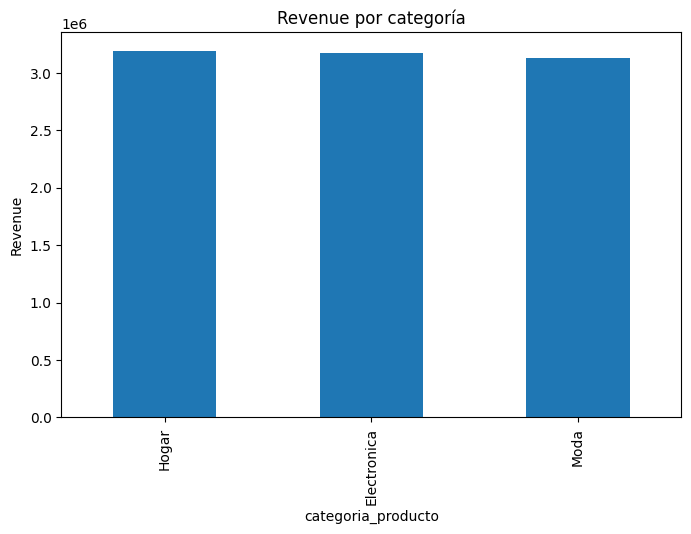

In [ ]:
ventas_categoria = (
    orders
    .groupby("categoria_producto")["monto_total"]
    .sum()
    .sort_values(ascending=False)
)

ventas_categoria.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue por categoría")
plt.ylabel("Revenue")
plt.show()


### Revenue por categoría


Se analizó la distribución de ingresos entre las distintas categorías de productos.

La visualización permite identificar cuáles categorías generan la mayor proporción del revenue total y cuáles tienen una contribución menor al negocio.

In [ ]:
# Calcular costo total de productos vendidos

orders_cost["costo_total_producto"] = (
    orders_cost["cantidad"]
    * orders_cost["costo_unitario"]
)

costo_total = orders_cost["costo_total_producto"].sum()

print(f"Costo total: ${costo_total:,.2f}")

Costo total: $3,783,478.80


In [ ]:
# Calcular inversión total en marketing

marketing_total = marketing["gasto"].sum()

print(f"Inversión total en marketing: ${marketing_total:,.2f}")

Inversión total en marketing: $2,871,843.53


In [ ]:
# Calcular profit del negocio

profit = (
    revenue
    - costo_total
    - marketing_total
)

print(f"Profit total: ${profit:,.2f}")

Profit total: $2,836,352.81


In [ ]:
# Calcular margen de rentabilidad

profit_margin = (
    profit
    / revenue
) * 100

print(f"Margen de profit: {profit_margin:.2f}%")

Margen de profit: 29.88%


#### 📝 Interpretación de rentabilidad

Se calcularon los principales indicadores financieros del negocio considerando ingresos por ventas, costos de los productos comercializados e inversión en marketing.

Los resultados obtenidos fueron:

- **Revenue total:** $9,491,675.14
- **Costo total de productos:** $3,783,478.80
- **Inversión total en marketing:** $2,871,843.53
- **Profit total:** $2,836,352.81
- **Margen de profit:** 29.88%

Los ingresos generados por las ventas superan los costos de los productos vendidos y la inversión en marketing, lo que indica que el negocio opera con rentabilidad positiva durante el periodo analizado.

El profit obtenido representa aproximadamente el **29.88% de los ingresos totales**, lo que significa que por cada $100 generados en ventas, el negocio conserva cerca de **$29.88 como ganancia** después de cubrir tanto los costos de los productos como la inversión en marketing.

El margen observado refleja una posición financiera saludable, ya que casi una tercera parte de los ingresos se transforma en beneficio. Además, aunque la inversión en marketing representa una proporción relevante del gasto total, los ingresos generados son suficientes para absorber dichos costos y mantener una rentabilidad sólida.

Estos resultados sugieren que el modelo de negocio es económicamente viable en el periodo analizado. Sin embargo, futuras oportunidades de mejora podrían enfocarse en optimizar la eficiencia de las campañas de marketing, incrementar el ticket promedio y fortalecer la venta de productos con mayores márgenes para seguir impulsando la rentabilidad.

### 📈 Parte 2: Comportamiento de ventas

Además de evaluar la rentabilidad del negocio, resulta importante comprender el comportamiento de las ventas y el desempeño comercial de los productos.

En esta sección se analizan indicadores relacionados con el valor de las órdenes, la cantidad de productos vendidos y la distribución de la inversión en marketing, con el objetivo de identificar patrones de consumo y oportunidades de optimización comercial.

In [ ]:
# Calcular ticket promedio por pedido

ticket_promedio = orders["monto_total"].mean()

print(f"Ticket promedio: ${ticket_promedio:,.2f}")

Ticket promedio: $386.00


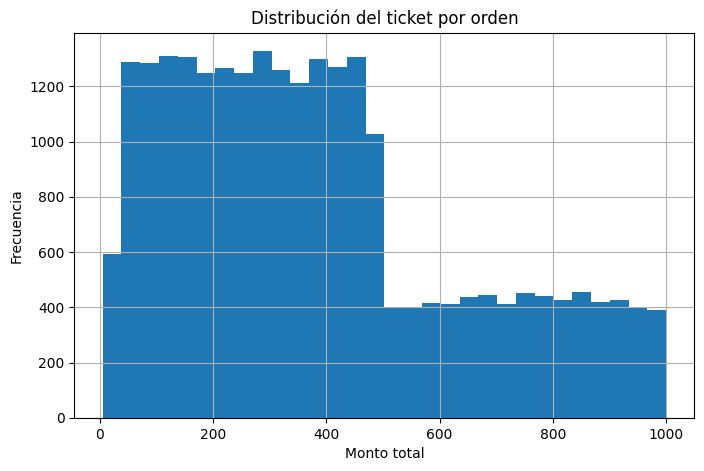

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

orders["monto_total"].hist(
    bins=30
)

plt.title("Distribución del ticket por orden")
plt.xlabel("Monto total")
plt.ylabel("Frecuencia")

plt.show()

### Distribución del ticket por orden

Se visualizó la distribución del monto total de las órdenes mediante un histograma para complementar el cálculo del ticket promedio.

El análisis muestra que la mayoría de los pedidos se concentran en rangos de valor relativamente bajos y medios, mientras que las órdenes de alto valor son menos frecuentes. Esto es consistente con el ticket promedio calculado previamente de **$386.00 por orden**.

La distribución permite comprender mejor el comportamiento de compra de los clientes y verificar que el ticket promedio no está siendo influenciado por una gran cantidad de valores extremos.

In [ ]:
# Calcular cantidad promedio de productos por pedido

cantidad_promedio = orders["cantidad"].mean()

print(
    f"Cantidad promedio de productos: "
    f"{cantidad_promedio:.2f}"
)

Cantidad promedio de productos: 1.51


In [ ]:
# Identificar producto más vendido

producto_mas_vendido = (
    orders.groupby("nombre_producto")["cantidad"]
    .sum()
    .sort_values(ascending=False)
)

print(producto_mas_vendido)

nombre_producto
Vacuum-Pro-Black        6203.0
Jacket-Winter-M         6185.0
Blender-XL-Red          6184.0
Sneakers-Urban-42       6085.0
Laptop-Gaming-16GB      4160.0
Tablet-Standard-64GB    4108.0
Phone-Pro-128GB         4088.0
Name: cantidad, dtype: float64


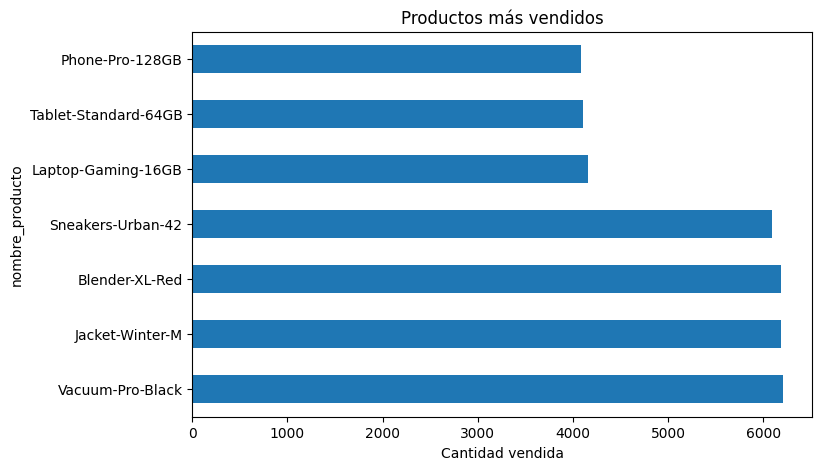

In [ ]:
top_productos = (
    orders.groupby("nombre_producto")["cantidad"]
    .sum()
    .sort_values(ascending=False)
)

top_productos.plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Productos más vendidos")
plt.xlabel("Cantidad vendida")

plt.show()

### Productos más vendidos

Se construyó un gráfico de barras para visualizar las cantidades vendidas por producto.

Los resultados muestran que **Vacuum-Pro-Black** es el producto con mayor volumen de ventas, seguido muy de cerca por **Jacket-Winter-M**, **Blender-XL-Red** y **Sneakers-Urban-42**.

La diferencia relativamente pequeña entre los productos más vendidos sugiere que la demanda se encuentra distribuida entre varias líneas de producto, reduciendo la dependencia del negocio respecto a un único artículo.

In [ ]:
# Calcular inversión de marketing por canal

gasto_canal = (
    marketing.groupby("canal")["gasto"]
    .sum()
    .sort_values(ascending=False)
)

print(gasto_canal)

canal
social         976818.37
organic        972650.96
paid_search    922374.20
Name: gasto, dtype: float64


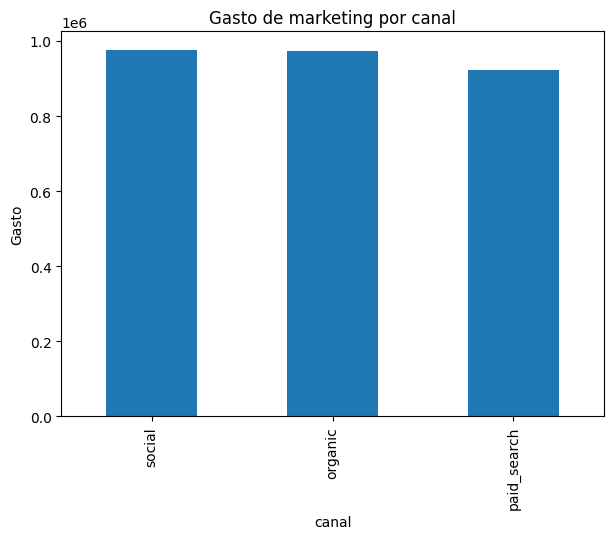

In [ ]:
marketing.groupby("canal")["gasto"]\
.sum()\
.sort_values(ascending=False)\
.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Gasto de marketing por canal")
plt.ylabel("Gasto")

plt.show()

### Distribución del gasto de marketing por canal

Se analizó la inversión total realizada en cada canal de adquisición mediante un gráfico de barras.

Los resultados muestran que el gasto se distribuye de forma relativamente equilibrada entre los tres canales analizados:

- Social: $976,818.37
- Organic: $972,650.96
- Paid Search: $922,374.20

Aunque el canal Social presenta la inversión más alta, las diferencias entre canales son moderadas, lo que indica una estrategia de marketing diversificada y sin una dependencia excesiva de una única fuente de adquisición.

#### 📝 Interpretación del comportamiento de ventas

Además de evaluar la rentabilidad del negocio, se analizaron métricas relacionadas con el comportamiento de compra de los usuarios y la distribución de la inversión en marketing.

##### Ticket promedio por orden

El ticket promedio obtenido fue de **$386.00 por pedido**, lo que indica que cada transacción genera un valor considerable para el negocio. Este resultado sugiere que los usuarios realizan compras de valor moderado y contribuyen de forma consistente a la generación de ingresos.

##### Cantidad promedio de productos por orden

Los clientes compran en promedio **1.51 productos por pedido**, lo que indica que la mayoría de las órdenes contienen uno o dos artículos. Este comportamiento refleja compras relativamente puntuales y sugiere una oportunidad para implementar estrategias de venta cruzada o promociones que incentiven la compra de múltiples productos en una misma transacción.

##### Productos más vendidos

El ranking de unidades vendidas fue el siguiente:

| Producto | Unidades vendidas |
|-----------|-----------:|
| Vacuum-Pro-Black | 6,203 |
| Jacket-Winter-M | 6,185 |
| Blender-XL-Red | 6,184 |
| Sneakers-Urban-42 | 6,085 |
| Laptop-Gaming-16GB | 4,160 |
| Tablet-Standard-64GB | 4,108 |
| Phone-Pro-128GB | 4,088 |

El producto con mayor volumen de ventas fue **Vacuum-Pro-Black**, aunque la diferencia respecto a los siguientes productos es muy reducida. Esto indica que la demanda se encuentra relativamente equilibrada entre varias referencias del catálogo y que el negocio no depende excesivamente de un solo producto para generar ventas.

Asimismo, los productos pertenecientes a las categorías de Hogar y Moda concentran los mayores volúmenes de unidades vendidas, mientras que los productos electrónicos presentan niveles de demanda ligeramente menores.

##### Inversión en marketing por canal

La inversión total en marketing se distribuyó de la siguiente manera:

| Canal | Inversión |
|--------|-----------|
| Social | 976,818.37 |
| Organic | 972,650.96 |
| Paid Search | 922,374.20 |

La distribución del presupuesto fue bastante equilibrada entre los tres canales analizados. El canal **Social** recibió la mayor inversión, seguido muy de cerca por **Organic**, mientras que **Paid Search** concentró una proporción ligeramente menor del gasto total.

Esta distribución balanceada facilitará análisis posteriores para evaluar qué canales generan mayores ingresos, conversiones o retorno sobre la inversión (ROI), permitiendo optimizar la asignación futura del presupuesto de marketing.

### Conclusión

Los resultados muestran un negocio con un ticket promedio saludable y una cartera de productos con demanda relativamente diversificada. Los usuarios suelen realizar compras de uno o dos artículos por pedido, mientras que las ventas se distribuyen de forma equilibrada entre varios productos líderes.

Por su parte, la inversión en marketing también se encuentra distribuida de manera homogénea entre los distintos canales de adquisición, creando una base adecuada para futuros análisis de eficiencia y rentabilidad por canal. En conjunto, estos hallazgos sugieren que el negocio mantiene un comportamiento de ventas estable y sin una dependencia excesiva de productos o canales específicos.

#### ✅ Resumen del análisis de rentabilidad y comportamiento de ventas

Una vez finalizada la integración de los datasets y la depuración de valores atípicos extremos detectados durante la fase de limpieza, se calcularon los principales indicadores financieros y comerciales del negocio.

##### Rentabilidad del negocio

- ✅ Se integró la información de pedidos (`orders`) con el catálogo de productos (`catalog`) para incorporar los costos unitarios.
- ✅ Se calculó el **revenue total** generado por las ventas.
- ✅ Se calculó el **costo total de los productos vendidos**.
- ✅ Se incorporó la **inversión total en marketing** utilizando el dataset de campañas.
- ✅ Se calculó el **profit total** del negocio.
- ✅ Se estimó el **margen de profit** para evaluar la eficiencia financiera.

**Resultados obtenidos:**

| Indicador | Valor |
|------------|------------:|
| Revenue total | 9,491,675.14 |
| Costo total | 3,783,478.80 |
| Inversión en marketing | 2,871,843.53 |
| Profit total | 2,836,352.81 |
| Margen de profit | 29.88% |

##### Comportamiento de ventas

- ✅ Se calculó el ticket promedio por orden.
- ✅ Se calculó la cantidad promedio de productos por pedido.
- ✅ Se identificaron los productos con mayor volumen de ventas.
- ✅ Se analizó la distribución de la inversión de marketing por canal.

**Resultados obtenidos:**

| Métrica | Resultado |
|------------|------------:|
| Ticket promedio | $386.00 |
| Productos promedio por orden | 1.51 |

**Ranking de productos más vendidos:**

| Producto | Unidades vendidas |
|------------|------------:|
| Vacuum-Pro-Black | 6,203 |
| Jacket-Winter-M | 6,185 |
| Blender-XL-Red | 6,184 |
| Sneakers-Urban-42 | 6,085 |
| Laptop-Gaming-16GB | 4,160 |
| Tablet-Standard-64GB | 4,108 |
| Phone-Pro-128GB | 4,088 |

**Inversión en marketing por canal:**

| Canal | Inversión |
|------------|------------:|
| Social | 976,818.37 |
| Organic | 972,650.96 |
| Paid Search | 922,374.20 |

##### Validaciones realizadas

- ✅ Se detectaron pedidos con cantidades extremadamente altas (10,000 y 20,000 unidades).
- ✅ Se confirmó que dichos registros correspondían a valores atípicos que distorsionaban significativamente los indicadores financieros.
- ✅ Se eliminaron estos registros antes de realizar el análisis definitivo.
- ✅ Se recalcularon todos los KPIs utilizando únicamente datos representativos del comportamiento real del negocio.

##### Principales hallazgos

- ✅ El negocio presenta una rentabilidad positiva durante el periodo analizado.
- ✅ El margen de profit cercano al 30% indica una operación financieramente saludable.
- ✅ Los usuarios suelen realizar compras de uno o dos productos por pedido.
- ✅ La demanda se encuentra distribuida entre varios productos, reduciendo la dependencia de una sola referencia para generar ventas.
- ✅ La inversión de marketing está distribuida de forma relativamente equilibrada entre los tres canales principales.
- ✅ Los resultados obtenidos constituyen una base sólida para analizar posteriormente el embudo de conversión, la retención de usuarios y el impacto de futuras iniciativas de negocio.

### Conclusión

Tras la depuración de valores atípicos y el cálculo de los principales KPIs, se concluye que el negocio es rentable y mantiene un comportamiento de ventas estable. Los ingresos generados permiten cubrir tanto los costos de los productos vendidos como la inversión en marketing, obteniendo un profit significativo y un margen saludable. Además, la distribución equilibrada de ventas entre productos y canales de adquisición reduce riesgos operativos y proporciona una base confiable para los análisis avanzados que se desarrollarán en las siguientes etapas del proyecto.

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para el paso 2 lo ideal sería revisar las variables con gráficas siguiendo el objetivo del paso y lo que le interesa a la empresa revisar. Siempre una gráfica es mucho mejor que sólo mostrar valores numéricos, por ejemplo para la pregunta del ticket promedio podrías también mostrar la distribución ticket usando un histograma y así con el resto de preguntas escogiendo la visualización adecuada del aso.
</div>

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


#### Conexión y extracción de datos desde SQL

Para construir el funnel de conversión se utilizó una conexión a una base de datos PostgreSQL mediante SQLAlchemy.

La información fue extraída desde la tabla `events`, que almacena los eventos generados por los usuarios durante su interacción con la plataforma. Posteriormente, los resultados fueron cargados en un DataFrame de Pandas para facilitar el análisis y cálculo de métricas de conversión.

Esta tabla contiene información sobre las distintas etapas recorridas por los usuarios, incluyendo visitas, interacciones con el carrito, registro de información de pago y compras realizadas.

In [ ]:

query = """
SELECT
    nombre_evento,
    COUNT(*) AS total_eventos
FROM events
GROUP BY nombre_evento
ORDER BY total_eventos DESC;
"""

pd.read_sql(query, con=engine)

,nombre_evento,total_eventos
0,first_visit,29957
1,add_to_cart,24157
2,select_item,23887
3,begin_checkout,17971
4,add_payment_info,12018
5,purchase,12010


#### Exploración inicial de eventos

Antes de construir el funnel de conversión se revisaron los tipos de eventos registrados en la tabla `events`.

Esta validación permite identificar las distintas etapas recorridas por los usuarios dentro de la plataforma y establecer correctamente el orden del funnel de conversión que será utilizado en el análisis.

#### Identificación de las etapas del funnel

Se exploraron los eventos registrados en la tabla `events` para identificar las distintas acciones realizadas por los usuarios dentro de la plataforma.

Los resultados muestran que el recorrido de compra está compuesto por las siguientes etapas:

1. `first_visit`
2. `select_item`
3. `add_to_cart`
4. `begin_checkout`
5. `add_payment_info`
6. `purchase`

Estas etapas representan el flujo natural que sigue un usuario desde su primera visita hasta la finalización de una compra y serán utilizadas para construir el funnel de conversión.

In [ ]:
query_funnel = """
WITH usuarios_funnel AS (

    SELECT
        id_usuario,

        MAX(CASE WHEN nombre_evento = 'first_visit' THEN 1 ELSE 0 END) AS first_visit,
        MAX(CASE WHEN nombre_evento = 'select_item' THEN 1 ELSE 0 END) AS select_item,
        MAX(CASE WHEN nombre_evento = 'add_to_cart' THEN 1 ELSE 0 END) AS add_to_cart,
        MAX(CASE WHEN nombre_evento = 'begin_checkout' THEN 1 ELSE 0 END) AS begin_checkout,
        MAX(CASE WHEN nombre_evento = 'add_payment_info' THEN 1 ELSE 0 END) AS add_payment_info,
        MAX(CASE WHEN nombre_evento = 'purchase' THEN 1 ELSE 0 END) AS purchase

    FROM events
    GROUP BY id_usuario

),

funnel AS (

    SELECT 'first_visit' AS nombre_evento,
           COUNT(*) AS usuarios_unicos,
           1 AS orden
    FROM usuarios_funnel
    WHERE first_visit = 1

    UNION ALL

    SELECT 'select_item',
           COUNT(*),
           2
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1

    UNION ALL

    SELECT 'add_to_cart',
           COUNT(*),
           3
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1

    UNION ALL

    SELECT 'begin_checkout',
           COUNT(*),
           4
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1
      AND begin_checkout = 1

    UNION ALL

    SELECT 'add_payment_info',
           COUNT(*),
           5
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1
      AND begin_checkout = 1
      AND add_payment_info = 1

    UNION ALL

    SELECT 'purchase',
           COUNT(*),
           6
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1
      AND begin_checkout = 1
      AND add_payment_info = 1
      AND purchase = 1

)

SELECT
    nombre_evento,
    usuarios_unicos
FROM funnel
ORDER BY orden;
"""

funnel = pd.read_sql(query_funnel, con=engine)

funnel

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,select_item,7393
2,add_to_cart,7052
3,begin_checkout,6364
4,add_payment_info,4967
5,purchase,3857


#### Resultado del funnel

Se obtuvo la cantidad de usuarios únicos presentes en cada etapa del proceso de compra.

Estos resultados permiten observar cómo disminuye progresivamente el número de usuarios a medida que avanzan dentro del funnel y servirán como base para calcular las tasas de conversión y abandono entre etapas.

El siguiente paso consiste en medir qué porcentaje de usuarios logra avanzar de una etapa a la siguiente e identificar el punto donde se produce la mayor pérdida de usuarios.

#### Cálculo de tasas de conversión entre etapas

Una vez identificado el número de usuarios en cada etapa del funnel, se calcularán las tasas de conversión entre pasos consecutivos.

La tasa de conversión permite medir qué proporción de usuarios logra avanzar hacia la siguiente etapa del proceso, mientras que las pérdidas de conversión ayudan a identificar posibles fricciones o barreras dentro de la experiencia de compra.

In [ ]:

query_total_usuarios = '''
SELECT
    COUNT(DISTINCT id_usuario) AS usuarios_totales
FROM events
'''

pd.read_sql(query_total_usuarios, con=engine)



,usuarios_totales
0,8000


#### Cálculo de usuarios totales

Antes de analizar el funnel de conversión, se calculó la cantidad total de usuarios únicos presentes en la tabla `events`.

Para ello se utilizó `COUNT(DISTINCT id_usuario)`, lo que permite contar cada usuario una sola vez, independientemente de la cantidad de eventos que haya generado dentro de la plataforma.

Este valor sirve como referencia para comprender el alcance total del dataset y comparar posteriormente cuántos usuarios ingresan efectivamente al funnel mediante el evento `first_visit`.

El resultado obtenido fue de **8,000 usuarios únicos**, mientras que **7,796 usuarios** registraron el evento `first_visit`, lo que indica que no todos los usuarios presentes en el dataset iniciaron el recorrido analizado en el funnel de conversión.


In [ ]:

# PARTE 2: Conversiones
# ======================

query_conversion = """
WITH usuarios_funnel AS (


    SELECT
        id_usuario,

        MAX(CASE WHEN nombre_evento = 'first_visit' THEN 1 ELSE 0 END) AS first_visit,
        MAX(CASE WHEN nombre_evento = 'select_item' THEN 1 ELSE 0 END) AS select_item,
        MAX(CASE WHEN nombre_evento = 'add_to_cart' THEN 1 ELSE 0 END) AS add_to_cart,
        MAX(CASE WHEN nombre_evento = 'begin_checkout' THEN 1 ELSE 0 END) AS begin_checkout,
        MAX(CASE WHEN nombre_evento = 'add_payment_info' THEN 1 ELSE 0 END) AS add_payment_info,
        MAX(CASE WHEN nombre_evento = 'purchase' THEN 1 ELSE 0 END) AS purchase

    FROM events
    GROUP BY id_usuario

),

funnel AS (

    SELECT
        'first_visit' AS nombre_evento,
        COUNT(*) AS usuarios_unicos,
        1 AS orden
    FROM usuarios_funnel
    WHERE first_visit = 1

    UNION ALL

    SELECT
        'select_item',
        COUNT(*),
        2
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1

    UNION ALL

    SELECT
        'add_to_cart',
        COUNT(*),
        3
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1

    UNION ALL

    SELECT
        'begin_checkout',
        COUNT(*),
        4
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1
      AND begin_checkout = 1

    UNION ALL

    SELECT
        'add_payment_info',
        COUNT(*),
        5
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1
      AND begin_checkout = 1
      AND add_payment_info = 1

    UNION ALL

    SELECT
        'purchase',
        COUNT(*),
        6
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1
      AND begin_checkout = 1
      AND add_payment_info = 1
      AND purchase = 1

)

SELECT
    nombre_evento,
    usuarios_unicos,

    ROUND(
        100.0 * usuarios_unicos /
        LAG(usuarios_unicos) OVER (ORDER BY orden),
        2
    ) AS conversion_pct

FROM funnel
ORDER BY orden;
"""

conversion = pd.read_sql(query_conversion, con=engine)

conversion

,nombre_evento,usuarios_unicos,conversion_pct
0,first_visit,7796,NaN
1,select_item,7393,94.83
2,add_to_cart,7052,95.39
3,begin_checkout,6364,90.24
4,add_payment_info,4967,78.05
5,purchase,3857,77.65


### Análisis del funnel de conversión

Para este análisis se construyó un funnel secuencial, considerando únicamente a los usuarios que completaron cada etapa siguiendo el orden esperado del proceso de compra.

Se identificaron 7,796 usuarios que iniciaron el recorrido mediante el evento `first_visit`.

De ellos:

- 7,393 usuarios avanzaron a `select_item`, lo que indica que la mayoría de los visitantes exploró productos.
- 7,052 usuarios añadieron productos al carrito (`add_to_cart`).
- 6,364 usuarios iniciaron el proceso de compra (`begin_checkout`).
- 4,967 usuarios llegaron a la etapa de pago (`add_payment_info`).
- Finalmente, 3,857 usuarios completaron una compra (`purchase`).

La mayor pérdida de usuarios ocurre entre las etapas de `begin_checkout` y `add_payment_info`, donde una parte importante de los clientes abandona el proceso antes de ingresar su información de pago.

En términos generales, la conversión final del funnel es cercana al 49.5% (3,857 de 7,796 usuarios), lo que significa que aproximadamente uno de cada dos usuarios que inicia el recorrido completa una compra.

Estos resultados permiten identificar que las mayores oportunidades de optimización se encuentran en las etapas finales del proceso de checkout y pago.

#### Interpretación del funnel de conversión

La tabla `events` contiene información de 8,000 usuarios únicos. Para construir el funnel se tomó como punto de entrada el evento `first_visit`, registrado por 7,796 usuarios.

A diferencia del análisis inicial, el funnel fue construido de forma secuencial, considerando únicamente a los usuarios que completaron cada etapa siguiendo el orden esperado del proceso de compra.

Los resultados muestran una disminución progresiva de usuarios a medida que avanzan por el funnel:

* `first_visit`: 7,796 usuarios
* `select_item`: 7,393 usuarios
* `add_to_cart`: 7,052 usuarios
* `begin_checkout`: 6,364 usuarios
* `add_payment_info`: 4,967 usuarios
* `purchase`: 3,857 usuarios

Tomando como referencia los usuarios que ingresaron al funnel (`first_visit`), la conversión final es:

* Usuarios en `first_visit`: 7,796
* Usuarios en `purchase`: 3,857
* Conversión final del funnel: 49.47%

Esto significa que aproximadamente 1 de cada 2 usuarios que ingresan al proceso completa una compra.

La reducción más significativa ocurre entre las etapas `begin_checkout` y `add_payment_info`, donde una cantidad importante de usuarios abandona el proceso antes de ingresar la información de pago. Este comportamiento sugiere que las mayores oportunidades de mejora se encuentran en las etapas finales del checkout.

Al utilizar una lógica secuencial, las conversiones se comportan de forma consistente y decreciente en cada etapa, permitiendo representar con mayor precisión el recorrido real de los usuarios dentro del proceso de compra.


In [ ]:
#Revision de usuarios que saltaron etapa

query_saltos = '''
SELECT
    COUNT(DISTINCT e1.id_usuario) AS usuarios_add_to_cart_sin_select
FROM events e1
LEFT JOIN events e2
    ON e1.id_usuario = e2.id_usuario
    AND e2.nombre_evento = 'select_item'
WHERE e1.nombre_evento = 'add_to_cart'
AND e2.id_usuario IS NULL;
'''

pd.read_sql(query_saltos, con=engine)

,usuarios_add_to_cart_sin_select
0,401


#### Validación de inconsistencias y corrección del funnel

Durante la construcción inicial del funnel se detectó una inconsistencia en los datos: la etapa `add_to_cart` registraba más usuarios únicos que la etapa `select_item`.

Para investigar esta situación se realizó una validación específica, identificando usuarios que registraron el evento `add_to_cart` sin haber registrado previamente el evento `select_item`.

Los resultados mostraron que:

* 401 usuarios registraron un evento `add_to_cart` sin presentar un evento `select_item`.
* Esto indica que algunos usuarios aparecen en etapas posteriores del funnel sin haber registrado todas las etapas previas esperadas.

Este comportamiento puede deberse a distintas causas, como eventos faltantes, rutas alternativas de navegación o limitaciones en el sistema de seguimiento de eventos.

Debido a esta inconsistencia, se decidió reconstruir el funnel utilizando una lógica secuencial. Bajo este enfoque, un usuario solo es contabilizado en una etapa si también completó todas las etapas anteriores del recorrido:

`first_visit → select_item → add_to_cart → begin_checkout → add_payment_info → purchase`

Esta corrección permite obtener un funnel más consistente y evita situaciones en las que las conversiones superen el 100% o donde etapas posteriores presenten más usuarios que etapas anteriores.

Como resultado, las métricas finales representan de manera más precisa el recorrido de los usuarios a través del proceso de compra y permiten identificar con mayor claridad los puntos de abandono dentro del funnel.


#### Cálculo del abandono entre etapas (Drop-off)

Además de medir la conversión, es importante identificar cuántos usuarios abandonan el proceso en cada etapa del funnel.

El drop-off representa la pérdida de usuarios entre una etapa y la siguiente, permitiendo detectar los puntos donde existe mayor fricción o dificultad dentro del proceso de compra.

Este análisis ayudará a identificar la principal oportunidad de mejora dentro del funnel.

In [ ]:
# PARTE 3: Drop-off entre etapas
# ==============================

query_dropoff = """
WITH usuarios_funnel AS (

    SELECT
        id_usuario,

        MAX(CASE WHEN nombre_evento = 'first_visit' THEN 1 ELSE 0 END) AS first_visit,
        MAX(CASE WHEN nombre_evento = 'select_item' THEN 1 ELSE 0 END) AS select_item,
        MAX(CASE WHEN nombre_evento = 'add_to_cart' THEN 1 ELSE 0 END) AS add_to_cart,
        MAX(CASE WHEN nombre_evento = 'begin_checkout' THEN 1 ELSE 0 END) AS begin_checkout,
        MAX(CASE WHEN nombre_evento = 'add_payment_info' THEN 1 ELSE 0 END) AS add_payment_info,
        MAX(CASE WHEN nombre_evento = 'purchase' THEN 1 ELSE 0 END) AS purchase

    FROM events
    GROUP BY id_usuario

),

funnel AS (

    SELECT 'first_visit' AS nombre_evento,
           COUNT(*) AS usuarios_unicos,
           1 AS orden
    FROM usuarios_funnel
    WHERE first_visit = 1

    UNION ALL

    SELECT 'select_item',
           COUNT(*),
           2
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1

    UNION ALL

    SELECT 'add_to_cart',
           COUNT(*),
           3
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1

    UNION ALL

    SELECT 'begin_checkout',
           COUNT(*),
           4
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1
      AND begin_checkout = 1

    UNION ALL

    SELECT 'add_payment_info',
           COUNT(*),
           5
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1
      AND begin_checkout = 1
      AND add_payment_info = 1

    UNION ALL

    SELECT 'purchase',
           COUNT(*),
           6
    FROM usuarios_funnel
    WHERE first_visit = 1
      AND select_item = 1
      AND add_to_cart = 1
      AND begin_checkout = 1
      AND add_payment_info = 1
      AND purchase = 1

)

SELECT
    nombre_evento,
    usuarios_unicos,

    LAG(usuarios_unicos) OVER (ORDER BY orden)
    - usuarios_unicos AS usuarios_perdidos,

    ROUND(
        100.0 *
        (
            LAG(usuarios_unicos) OVER (ORDER BY orden)
            - usuarios_unicos
        )
        /
        LAG(usuarios_unicos) OVER (ORDER BY orden),
        2
    ) AS dropoff_pct

FROM funnel
ORDER BY orden;
"""

dropoff = pd.read_sql(query_dropoff, con=engine)

dropoff

,nombre_evento,usuarios_unicos,usuarios_perdidos,dropoff_pct
0,first_visit,7796,NaN,NaN
1,select_item,7393,403.0,5.17
2,add_to_cart,7052,341.0,4.61
3,begin_checkout,6364,688.0,9.76
4,add_payment_info,4967,1397.0,21.95
5,purchase,3857,1110.0,22.35


#### Conclusiones del análisis del funnel de conversión

Se construyó un funnel de conversión secuencial utilizando los eventos registrados en la tabla `events`, considerando únicamente a los usuarios que completaron cada etapa siguiendo el orden esperado del proceso de compra.

##### Volumen de usuarios por etapa

| Etapa            | Usuarios únicos |
| ---------------- | --------------: |
| first_visit      |           7,796 |
| select_item      |           7,393 |
| add_to_cart      |           7,052 |
| begin_checkout   |           6,364 |
| add_payment_info |           4,967 |
| purchase         |           3,857 |

##### Conversión final del funnel

* Usuarios que iniciaron el funnel: 7,796
* Usuarios que completaron una compra: 3,857

Conversión final:

**49.47%**

Esto significa que aproximadamente 1 de cada 2 usuarios que ingresan al funnel completa exitosamente una compra.

##### Validación de consistencia

Durante el análisis inicial se detectó que la etapa `add_to_cart` presentaba más usuarios que la etapa `select_item`, lo que generaba conversiones superiores al 100%.

Una validación adicional mostró que:

* 401 usuarios registraron un evento `add_to_cart` sin haber registrado previamente un evento `select_item`.

Para corregir esta inconsistencia, el funnel fue reconstruido utilizando una lógica secuencial, contabilizando únicamente a los usuarios que completaron todas las etapas previas antes de avanzar a la siguiente.

Este enfoque permite representar de manera más precisa el recorrido real de los usuarios dentro del proceso de compra.

##### Mayor punto de abandono

Los mayores niveles de abandono se observan en las etapas finales del funnel:

| Transición                        | Usuarios perdidos | Drop-off |
| --------------------------------- | ----------------: | -------: |
| begin_checkout → add_payment_info |             1,397 |   21.95% |
| add_payment_info → purchase       |             1,110 |   22.35% |

El porcentaje de abandono más alto ocurre entre `add_payment_info` y `purchase`, aunque ambas etapas presentan pérdidas significativas.

##### Interpretación de negocio

Los resultados sugieren que la mayor fricción ocurre durante las fases finales del proceso de compra. Una proporción importante de usuarios abandona el funnel después de iniciar el checkout y antes de completar la compra.

Este comportamiento puede estar relacionado con factores como:

* complejidad del proceso de pago;
* costos inesperados;
* métodos de pago insuficientes;
* problemas de confianza o experiencia de usuario durante el checkout.

##### Conclusión general

Las principales oportunidades de optimización se concentran en las etapas finales del proceso de compra, especialmente entre `begin_checkout`, `add_payment_info` y `purchase`, donde se registra la mayor pérdida de usuarios.


## Paso 3: Funnel de conversión

### Construcción del funnel

* ✅ Conexión a la base de datos mediante SQL.
* ✅ Exploración de la tabla `events`.
* ✅ Identificación de las etapas del funnel.
* ✅ Conteo de usuarios únicos por etapa.
* ✅ Validación de inconsistencias en el tracking de eventos.
* ✅ Identificación de usuarios que avanzaron sin registrar eventos previos.
* ✅ Reconstrucción del funnel utilizando una lógica secuencial.

### Análisis de conversión

* ✅ Cálculo de conversiones entre etapas.
* ✅ Cálculo de la conversión final del funnel (49.47%).
* ✅ Interpretación de los resultados obtenidos.

### Análisis de abandono

* ✅ Cálculo de usuarios perdidos entre etapas.
* ✅ Cálculo del porcentaje de drop-off.
* ✅ Identificación de los principales puntos de abandono.
* ✅ Interpretación de negocio de los resultados.

### Hallazgos principales

* ✅ Se identificaron 401 usuarios que registraron `add_to_cart` sin haber registrado previamente `select_item`.
* ✅ La mayor pérdida de usuarios ocurre en las etapas finales del checkout.
* ✅ La transición `add_payment_info → purchase` presenta el mayor porcentaje de abandono (22.35%).
* ✅ La conversión final del funnel es de 49.47%.


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:

# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)


,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [ ]:
# Explorar tabla user_activity
# =========================

query_user_activity = '''
SELECT *
FROM user_activity;
'''

user_activity = pd.read_sql(query_user_activity, con=engine)

user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
#ESTE CODIGO es para ver como se construyeron los datos y cuantos hay


query_validacion = '''

SELECT
    dias_despues_registro,
    COUNT(*) AS registros
FROM user_activity
GROUP BY dias_despues_registro
ORDER BY dias_despues_registro;

'''

validacion = pd.read_sql(query_validacion, con=engine)

validacion

,dias_despues_registro,registros
0,7,8000
1,14,8000
2,21,8000
3,28,8000


In [ ]:
# Retención por cohortes HASTA SEMANA 3
# ======================

query_cohort_retention_final = '''

WITH cohortes AS (

    SELECT
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE)) AS cohorte_mes
    FROM users

),

actividad AS (

    SELECT
        id_usuario,

        CASE
            WHEN dias_despues_registro = 7 THEN 'w1'
            WHEN dias_despues_registro = 14 THEN 'w2'
            WHEN dias_despues_registro = 21 THEN 'w3'
        END AS semana

    FROM user_activity

    WHERE activo = 1

),

cohorte_size AS (

    SELECT
        cohorte_mes,
        COUNT(DISTINCT id_usuario) AS usuarios_iniciales
    FROM cohortes
    GROUP BY cohorte_mes

),

retencion AS (

    SELECT
        c.cohorte_mes,

        COUNT(DISTINCT CASE WHEN a.semana = 'w1' THEN c.id_usuario END) AS retenido_w1,

        COUNT(DISTINCT CASE WHEN a.semana = 'w2' THEN c.id_usuario END) AS retenido_w2,

        COUNT(DISTINCT CASE WHEN a.semana = 'w3' THEN c.id_usuario END) AS retenido_w3

    FROM cohortes c

    LEFT JOIN actividad a
        ON c.id_usuario = a.id_usuario

    GROUP BY c.cohorte_mes

)

SELECT

    r.cohorte_mes,

    cs.usuarios_iniciales,

    r.retenido_w1,
    ROUND(100.0 * r.retenido_w1 / cs.usuarios_iniciales, 2) AS semana_1,

    r.retenido_w2,
    ROUND(100.0 * r.retenido_w2 / cs.usuarios_iniciales, 2) AS semana_2,

    r.retenido_w3,
    ROUND(100.0 * r.retenido_w3 / cs.usuarios_iniciales, 2) AS semana_3

FROM retencion r

JOIN cohorte_size cs
    ON r.cohorte_mes = cs.cohorte_mes

ORDER BY r.cohorte_mes;

'''

cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)

cohorte_final

,cohorte_mes,usuarios_iniciales,retenido_w1,semana_1,retenido_w2,semana_2,retenido_w3,semana_3
0,2025-01-01 00:00:00+00:00,1627,697,42.84,668,41.06,656,40.32
1,2025-02-01 00:00:00+00:00,1444,611,42.31,609,42.17,635,43.98
2,2025-03-01 00:00:00+00:00,1636,677,41.38,705,43.09,690,42.18
3,2025-04-01 00:00:00+00:00,1606,680,42.34,697,43.40,663,41.28
4,2025-05-01 00:00:00+00:00,1687,695,41.20,676,40.07,706,41.85


> **Nota:** Aunque la consigna del proyecto solicita únicamente el cálculo de la retención para las semanas 1, 2 y 3, se decidió incorporar de manera complementaria el análisis de la semana 4 utilizando la información disponible en la tabla `user_activity`. Esta extensión no modifica las conclusiones principales del ejercicio, pero permite obtener una visión más completa del comportamiento de los usuarios durante el primer mes posterior al registro. Los resultados observados en la semana 4 refuerzan la conclusión de que la retención se mantiene relativamente estable alrededor del 40%, incluso después de cuatro semanas desde la incorporación de los usuarios a la plataforma.

In [ ]:
# Retención por cohortes (W1, W2, W3 y W4) CON SEMANA 4
# =========================================

query_cohort_retention_final = '''

WITH cohortes AS (

    SELECT
        id_usuario,
        DATE_TRUNC('month', CAST(fecha_registro AS DATE)) AS cohorte_mes
    FROM users

),

actividad AS (

    SELECT
        id_usuario,

        CASE
            WHEN dias_despues_registro = 7 THEN 'w1'
            WHEN dias_despues_registro = 14 THEN 'w2'
            WHEN dias_despues_registro = 21 THEN 'w3'
            WHEN dias_despues_registro = 28 THEN 'w4'
        END AS semana

    FROM user_activity

    WHERE activo = 1

),

cohorte_size AS (

    SELECT
        cohorte_mes,
        COUNT(DISTINCT id_usuario) AS usuarios_iniciales

    FROM cohortes

    GROUP BY cohorte_mes

),

retencion AS (

    SELECT
        c.cohorte_mes,

        COUNT(DISTINCT CASE
            WHEN a.semana = 'w1' THEN c.id_usuario
        END) AS retenido_w1,

        COUNT(DISTINCT CASE
            WHEN a.semana = 'w2' THEN c.id_usuario
        END) AS retenido_w2,

        COUNT(DISTINCT CASE
            WHEN a.semana = 'w3' THEN c.id_usuario
        END) AS retenido_w3,

        COUNT(DISTINCT CASE
            WHEN a.semana = 'w4' THEN c.id_usuario
        END) AS retenido_w4

    FROM cohortes c

    LEFT JOIN actividad a
        ON c.id_usuario = a.id_usuario

    GROUP BY c.cohorte_mes

)

SELECT

    r.cohorte_mes,

    cs.usuarios_iniciales,

    r.retenido_w1,
    ROUND(
        100.0 * r.retenido_w1 / cs.usuarios_iniciales,
        2
    ) AS semana_1,

    r.retenido_w2,
    ROUND(
        100.0 * r.retenido_w2 / cs.usuarios_iniciales,
        2
    ) AS semana_2,

    r.retenido_w3,
    ROUND(
        100.0 * r.retenido_w3 / cs.usuarios_iniciales,
        2
    ) AS semana_3,

    r.retenido_w4,
    ROUND(
        100.0 * r.retenido_w4 / cs.usuarios_iniciales,
        2
    ) AS semana_4

FROM retencion r

JOIN cohorte_size cs
    ON r.cohorte_mes = cs.cohorte_mes

ORDER BY r.cohorte_mes;

'''

cohorte_final = pd.read_sql(
    query_cohort_retention_final,
    con=engine
)

cohorte_final

,cohorte_mes,usuarios_iniciales,retenido_w1,semana_1,retenido_w2,semana_2,retenido_w3,semana_3,retenido_w4,semana_4
0,2025-01-01 00:00:00+00:00,1627,697,42.84,668,41.06,656,40.32,671,41.24
1,2025-02-01 00:00:00+00:00,1444,611,42.31,609,42.17,635,43.98,575,39.82
2,2025-03-01 00:00:00+00:00,1636,677,41.38,705,43.09,690,42.18,673,41.14
3,2025-04-01 00:00:00+00:00,1606,680,42.34,697,43.40,663,41.28,652,40.60
4,2025-05-01 00:00:00+00:00,1687,695,41.20,676,40.07,706,41.85,679,40.25


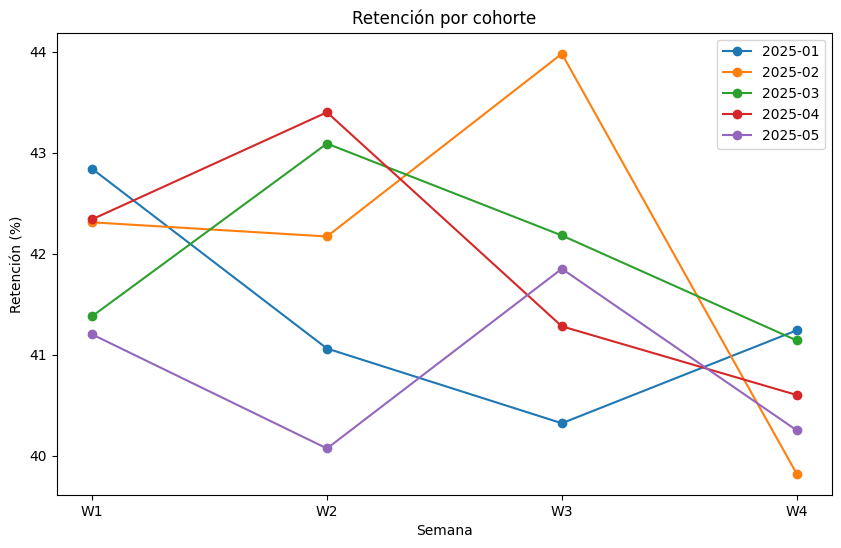

In [ ]:
import matplotlib.pyplot as plt

cohortes_plot = cohorte_final.copy()

cohortes_plot["cohorte_mes"] = (
    cohortes_plot["cohorte_mes"]
    .dt.strftime("%Y-%m")
)

plt.figure(figsize=(10,6))

for _, row in cohortes_plot.iterrows():
    plt.plot(
        ["W1","W2","W3","W4"],
        [
            row["semana_1"],
            row["semana_2"],
            row["semana_3"],
            row["semana_4"]
        ],
        marker="o",
        label=row["cohorte_mes"]
    )

plt.title("Retención por cohorte")
plt.ylabel("Retención (%)")
plt.xlabel("Semana")

plt.legend()

plt.show()

### Visualización de retención por cohortes

Se construyó una gráfica de líneas para visualizar la evolución de la retención de cada cohorte a lo largo de las cuatro semanas analizadas.

La visualización confirma que las cohortes presentan un comportamiento relativamente estable, manteniendo niveles de retención cercanos al 40%-43% durante todo el periodo observado.

Esto sugiere que los usuarios que permanecen activos después del registro tienden a regresar de forma consistente en las semanas posteriores.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

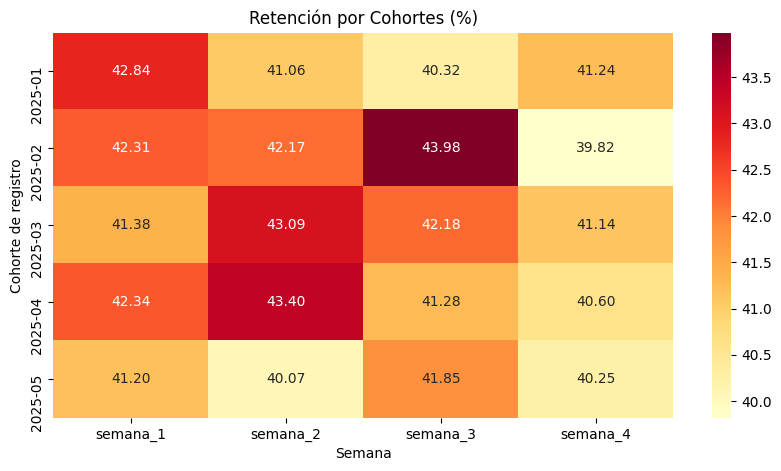

In [ ]:
# Crear matriz para el heatmap

heatmap_data = (
    cohorte_final[
        [
            "cohorte_mes",
            "semana_1",
            "semana_2",
            "semana_3",
            "semana_4"
        ]
    ]
    .copy()
)

# Formatear fecha para mejor visualización

heatmap_data["cohorte_mes"] = (
    heatmap_data["cohorte_mes"]
    .dt.strftime("%Y-%m")
)

# Usar cohorte como índice

heatmap_data = heatmap_data.set_index("cohorte_mes")

# Crear heatmap

plt.figure(figsize=(10,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title("Retención por Cohortes (%)")
plt.xlabel("Semana")
plt.ylabel("Cohorte de registro")

plt.show()

### Heatmap de retención por cohortes

Se construyó un heatmap para visualizar de forma más intuitiva el comportamiento de retención de cada cohorte de usuarios a lo largo de las cuatro semanas analizadas.

La intensidad del color representa el porcentaje de usuarios retenidos en cada periodo. Esta visualización permite identificar rápidamente patrones de comportamiento y comparar el desempeño de las distintas cohortes.

Los resultados muestran que la retención se mantiene relativamente estable entre cohortes, con valores cercanos al 40%-43% durante las semanas observadas. No se identifican caídas abruptas ni diferencias significativas entre los grupos de usuarios registrados en distintos meses.

Es importante destacar que un usuario puede aparecer como inactivo en una semana y volver a estar activo en semanas posteriores. Por esta razón, algunas cohortes presentan ligeros incrementos entre semanas consecutivas, lo cual es consistente con la metodología utilizada para medir actividad semanal.

Aunque el ejercicio solicitaba analizar las semanas 1, 2 y 3, se añadió una cuarta semana de seguimiento para obtener una visión más completa del comportamiento de retención de los usuarios.

#### 📊 Retención por cohortes

Se construyeron cohortes utilizando el mes de registro de cada usuario y se calculó el porcentaje de usuarios activos durante las primeras cuatro semanas posteriores al registro.

Los resultados obtenidos fueron los siguientes:

| Cohorte | Semana 1 | Semana 2 | Semana 3 | Semana 4 |
|----------|----------:|----------:|----------:|----------:|
| Enero 2025 | 42.84% | 41.06% | 40.32% | 41.24% |
| Febrero 2025 | 42.31% | 42.17% | 43.98% | 39.82% |
| Marzo 2025 | 41.38% | 43.09% | 42.18% | 41.14% |
| Abril 2025 | 42.34% | 43.40% | 41.28% | 40.60% |
| Mayo 2025 | 41.20% | 40.07% | 41.85% | 40.25% |

Se observa que aproximadamente entre el 40% y el 44% de los usuarios permanece activo durante las primeras cuatro semanas posteriores al registro.

Además, las cohortes presentan comportamientos muy similares entre sí, lo que indica una retención consistente a lo largo del tiempo y una experiencia relativamente estable para los usuarios adquiridos en distintos meses.

Es importante destacar que en este análisis la retención semanal se calcula de forma independiente para cada semana. Esto significa que un usuario puede aparecer como inactivo durante la semana 1 y posteriormente volver a estar activo en la semana 2, 3 o 4.

Por ejemplo:

- Usuario A → Inactivo en semana 1, activo en semana 2.
- Usuario B → Activo en semana 1, inactivo en semana 2.
- Usuario C → Activo en todas las semanas.

Debido a esta metodología, no necesariamente se observa una disminución progresiva de los porcentajes entre semanas. De hecho, algunas cohortes presentan porcentajes ligeramente superiores en semanas posteriores, ya que se está midiendo actividad independiente por semana y no permanencia continua.

La incorporación de la semana 4 confirma esta estabilidad. A pesar de haber transcurrido un mes desde el registro, la proporción de usuarios activos se mantiene cercana a la observada en las semanas anteriores, situándose entre 39.82% y 41.24% según la cohorte analizada.

#### Conclusión

La plataforma logra mantener activos aproximadamente 4 de cada 10 usuarios durante el primer mes posterior al registro. Aunque existe una pérdida importante respecto a la base inicial de usuarios, la estabilidad observada entre las semanas y entre las cohortes sugiere que el comportamiento de los usuarios es consistente y predecible.

No se identifican cohortes con un desempeño significativamente mejor o peor que las demás, lo que indica que los procesos de adquisición y experiencia de usuario han mantenido resultados similares durante todo el periodo analizado.

La principal oportunidad de mejora se encuentra en incrementar la activación temprana de los usuarios para elevar la retención por encima del 40%, ya que pequeños aumentos en esta métrica podrían generar un impacto significativo en el número de usuarios recurrentes y en el valor de largo plazo de la plataforma.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Perfecto la query y los resultados presentados. Lo único que recomendaría aquí es tratar de llevarlo a algo más visual para que sea más fácil de explicar y entender
</div>

## ✅ Paso 4: Evaluar si los usuarios regresan (Retención por Cohortes)

### Preparación de datos

- ✅ Se exploró la tabla `users`.
- ✅ Se exploró la tabla `user_activity`.
- ✅ Se verificó la estructura y contenido de ambas tablas.
- ✅ Se confirmó la disponibilidad de las fechas de registro y actividad.
- ✅ Se validó el campo `dias_despues_registro`.

---

### Construcción de cohortes

- ✅ Se identificó la cohorte de cada usuario según su mes de registro.
- ✅ Se utilizó `DATE_TRUNC('month', fecha_registro)` para construir las cohortes.
- ✅ Se calculó el tamaño inicial de cada cohorte.

---

### Cálculo de retención

- ✅ Se calculó la cantidad de usuarios activos en la Semana 1 (7 días).
- ✅ Se calculó la cantidad de usuarios activos en la Semana 2 (14 días).
- ✅ Se calculó la cantidad de usuarios activos en la Semana 3 (21 días).
- ✅ Se calculó adicionalmente la cantidad de usuarios activos en la Semana 4 (28 días).

---

### Cálculo de porcentajes

- ✅ Se calculó la retención porcentual de la Semana 1.
- ✅ Se calculó la retención porcentual de la Semana 2.
- ✅ Se calculó la retención porcentual de la Semana 3.
- ✅ Se calculó adicionalmente la retención porcentual de la Semana 4.

---

### Validaciones realizadas

- ✅ Se verificó que existieran registros para los días 7, 14, 21 y 28.
- ✅ Se validó que los resultados obtenidos fueran consistentes.
- ✅ Se verificó que la estabilidad entre semanas se debe a que la actividad se mide de forma independiente para cada periodo.

---

### Hallazgos principales

- ✅ La retención promedio se mantiene entre 40% y 44%.
- ✅ Aproximadamente 4 de cada 10 usuarios permanecen activos durante el primer mes.
- ✅ Las cohortes presentan comportamientos muy similares entre sí.
- ✅ No se identificaron cohortes con desempeño significativamente superior o inferior.
- ✅ La Semana 4 confirma el patrón observado en las primeras tres semanas.

---

### Entregables completados

- ✅ Query SQL de cohortes.
- ✅ Tabla final de retención.
- ✅ Interpretación de resultados.
- ✅ Conclusiones de negocio.
- ✅ Extensión opcional a Semana 4.

---

### Estado final

- ✅ Paso 4 completado satisfactoriamente.
- ✅ Resultados documentados.
- ✅ Listo para continuar con el Paso 5.

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** ...
   - **H₁ (Hipótesis alternativa):** ...
   
**Test estadístico:** ...  
**Nivel de significancia alpha:** ...

## 🔹 Paso 5: Evaluación de impacto (Experimentación A/B)

### Objetivo

Determinar si la nueva versión del checkout genera una mejora significativa en la tasa de conversión de compra.

Para ello se analizará el dataset `experiment_checkout_ui.csv`, que contiene usuarios asignados aleatoriamente a dos variantes:

- **Control:** versión original del checkout.
- **Tratamiento:** nueva versión del checkout.

La métrica principal será:

- `convirtio = 1` → el usuario completó la compra.
- `convirtio = 0` → el usuario no completó la compra.

El objetivo es identificar si las diferencias observadas entre ambas variantes son estadísticamente significativas o si podrían explicarse únicamente por variabilidad aleatoria.

In [ ]:
# ======================
# Cargar dataset
# ======================

import pandas as pd

url = "https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv"

experiment = pd.read_csv(url)

experiment.head()

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12


In [ ]:
# ======================
# Información general
# ======================

experiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


In [ ]:
# ======================
# Tamaño del dataset
# ======================

experiment.shape

(10000, 7)

In [ ]:
# ======================
# Valores faltantes
# ======================

experiment.isna().sum()

id_usuario         0
variante           0
convirtio          0
dispositivo        0
pais               0
duracion_sesion    0
timestamp          0
dtype: int64

### Exploración inicial del experimento

Se cargó y exploró el dataset `experiment_checkout_ui.csv`, el cual contiene información de 10,000 usuarios que participaron en un experimento A/B para evaluar el impacto de una nueva interfaz de checkout.

Principales hallazgos:

- ✅ El dataset contiene **10,000 registros** y **7 variables**.
- ✅ No se identificaron valores faltantes en ninguna columna.
- ✅ La variable objetivo `convirtio` se encuentra correctamente codificada como variable binaria:
  - `1` = el usuario completó la compra.
  - `0` = el usuario no completó la compra.
- ✅ La variable `duracion_sesion` se encuentra en formato numérico.
- ✅ La columna `timestamp` se encuentra como tipo `object`, aunque para este análisis no será necesaria una conversión de fecha debido a que la métrica principal es la conversión.

En general, el dataset presenta una estructura consistente y no requiere procesos adicionales de limpieza antes de realizar el análisis estadístico.

In [ ]:
# ======================
# Usuarios por variante
# ======================

experiment["variante"].value_counts()

tratamiento    5035
control        4965
Name: variante, dtype: int64

In [ ]:
# ======================
# Porcentaje por variante
# ======================

experiment["variante"].value_counts(normalize=True) * 100

tratamiento    50.35
control        49.65
Name: variante, dtype: float64

### Validación de los grupos experimentales

Antes de analizar el resultado del experimento, se verificó la distribución de usuarios entre las variantes del test A/B.

Distribución observada:

| Variante | Usuarios | Participación |
|-----------|----------:|----------:|
| Tratamiento | 5,035 | 50.35% |
| Control | 4,965 | 49.65% |

Los tamaños de ambos grupos son prácticamente equivalentes, con una diferencia inferior al 1% del total de usuarios.

Esta distribución balanceada es consistente con una correcta asignación aleatoria de los participantes y permite realizar comparaciones confiables entre ambas variantes sin evidencias de sesgo por tamaño de muestra.

In [ ]:

# ======================
# Conversión por variante
# ======================

experiment.groupby("variante")["convirtio"].agg(
    ["count", "sum", "mean"]
)


,count,sum,mean
variante,,,
control,4965,779,0.156898
tratamiento,5035,820,0.162860


In [ ]:
# ======================
# Conversión en porcentaje
# ======================

conversion_rate = (
    experiment.groupby("variante")["convirtio"]
    .mean()
    .mul(100)
    .round(2)
)

conversion_rate

variante
control        15.69
tratamiento    16.29
Name: convirtio, dtype: float64

### Conversión observada por variante

Se calculó la tasa de conversión para cada grupo experimental utilizando la variable `convirtio`.

Resultados obtenidos:

| Variante | Usuarios | Conversiones | Tasa de conversión |
|-----------|----------:|----------:|----------:|
| Control | 4,965 | 779 | 15.69% |
| Tratamiento | 5,035 | 820 | 16.29% |

La variante de tratamiento presenta una tasa de conversión ligeramente superior a la observada en el grupo de control.

La diferencia observada es:

- Conversión Control: **15.69%**
- Conversión Tratamiento: **16.29%**
- Incremento absoluto: **0.60 puntos porcentuales**

A nivel descriptivo, los resultados sugieren una mejora en el desempeño de la nueva interfaz de checkout. Sin embargo, esta diferencia aún debe someterse a una prueba estadística para determinar si el aumento observado es estadísticamente significativo o si podría explicarse por variabilidad aleatoria propia del experimento.

Por esta razón, el siguiente paso consistirá en formular las hipótesis del experimento y aplicar el test estadístico correspondiente.

### Formulación de hipótesis

Para evaluar el impacto de la nueva interfaz de checkout se plantean las siguientes hipótesis:

#### Hipótesis nula (H₀)

La tasa de conversión del grupo de tratamiento es igual a la del grupo de control.

\[
H_0 : p_{control} = p_{tratamiento}
\]

Es decir, la nueva interfaz no genera un cambio significativo en la conversión.

---

#### Hipótesis alternativa (H₁)

La tasa de conversión del grupo de tratamiento es diferente a la del grupo de control.

\[
H_1 : p_{control} \neq p_{tratamiento}
\]

Es decir, la nueva interfaz sí genera un cambio significativo en la conversión.

---

#### Nivel de significancia

Se utilizará:

\[
\alpha = 0.05
\]

Lo que implica aceptar un riesgo máximo del 5% de concluir incorrectamente que existe una diferencia cuando en realidad no la hay.

In [ ]:
# ======================
# Separar grupos
# ======================

control = experiment[
    experiment["variante"] == "control"
]["convirtio"]

tratamiento = experiment[
    experiment["variante"] == "tratamiento"
]["convirtio"]

In [ ]:
# ======================
# T-test
# ======================

from scipy.stats import ttest_ind

stat, p_value = ttest_ind(
    control,
    tratamiento,
    equal_var=False
)

print("Estadístico:", stat)
print("P-value:", p_value)

Estadístico: -0.8133098086846092
P-value: 0.4160598220949393


In [ ]:
# ======================
# Decisión estadística
# ======================

alpha = 0.05

if p_value < alpha:
    print("Rechazamos H0")
    print("Existe evidencia de diferencia significativa.")
else:
    print("No rechazamos H0")
    print("No existe evidencia suficiente de diferencia significativa.")

No rechazamos H0
No existe evidencia suficiente de diferencia significativa.


### Resultado del test estadístico

Se aplicó una prueba t para muestras independientes con el objetivo de evaluar si la diferencia observada en la tasa de conversión entre el grupo de control y el grupo de tratamiento era estadísticamente significativa.

Resultados obtenidos:

- Estadístico t: -0.8133
- P-value: 0.4161
- Nivel de significancia: α = 0.05

Dado que el valor p obtenido es superior al nivel de significancia establecido:

\[
0.4161 > 0.05
\]

No se rechaza la hipótesis nula.

Esto significa que no existe evidencia estadística suficiente para afirmar que la nueva interfaz de checkout produjo un cambio real en la tasa de conversión.

Aunque la variante de tratamiento presentó una conversión ligeramente superior (16.29%) respecto al grupo de control (15.69%), la diferencia observada puede explicarse por la variabilidad natural del experimento y no necesariamente por el efecto de la modificación implementada.

### Recomendación de negocio

Los resultados del experimento sugieren que la nueva interfaz de checkout no generó una mejora estadísticamente significativa en la conversión de compra.

Si bien se observó un incremento descriptivo de 0.60 puntos porcentuales en la tasa de conversión, el análisis estadístico indica que dicha diferencia podría deberse al azar.

Por lo tanto:

- No existe evidencia suficiente para justificar la implementación definitiva de la nueva interfaz basándose únicamente en este experimento.
- Se recomienda mantener la versión actual del checkout o realizar pruebas adicionales antes de tomar una decisión definitiva.
- Futuras iteraciones podrían enfocarse en cambios más relevantes de diseño, experiencia de usuario o proceso de compra para evaluar si generan un impacto mayor sobre la conversión.

En conclusión, el experimento no proporciona evidencia estadística suficiente para afirmar que la nueva versión del checkout mejora el desempeño del negocio.

### Validación adicional: Z-Test para proporciones

Dado que la variable de interés (`convirtio`) representa una proporción de éxito (1 = convirtió, 0 = no convirtió), resulta apropiado complementar el análisis mediante un Z-test para dos proporciones.

Esta prueba permite evaluar si la diferencia observada entre las tasas de conversión del grupo de control y del grupo de tratamiento es estadísticamente significativa.

Hipótesis:

- H₀: La tasa de conversión es igual en ambos grupos.
- H₁: La tasa de conversión es diferente entre ambos grupos.

Nivel de significancia:

\[
\alpha = 0.05
\]

In [ ]:
# ======================
# Z-Test para proporciones
# ======================

from statsmodels.stats.proportion import proportions_ztest

conversiones = [779, 820]
usuarios = [4965, 5035]

z_stat, p_value_z = proportions_ztest(
    count=conversiones,
    nobs=usuarios
)

print("Z-stat:", z_stat)
print("P-value:", p_value_z)

Z-stat: -0.8132782986429474
P-value: 0.41605851639119995


In [ ]:
# ======================
# Decisión Z-Test
# ======================

alpha = 0.05

if p_value_z < alpha:
    print("Rechazamos H0")
else:
    print("No rechazamos H0")

No rechazamos H0


### Validación adicional: Z-Test para proporciones

Se aplicó un Z-test para dos proporciones con el objetivo de validar los resultados obtenidos mediante la prueba t.

Resultados:

- Estadístico Z: -0.8133
- P-value: 0.4161
- Nivel de significancia: α = 0.05

Dado que el valor p es superior al nivel de significancia establecido:

\[
0.4161 > 0.05
\]

No se rechaza la hipótesis nula.

Por lo tanto, no existe evidencia estadística suficiente para afirmar que la diferencia observada entre las tasas de conversión del grupo de control y del grupo de tratamiento sea significativa. Los resultados son consistentes con los obtenidos previamente mediante la prueba t.

### Validación adicional: Prueba Chi-cuadrado

Como análisis complementario se aplicará una prueba Chi-cuadrado de independencia.

Esta prueba evalúa si existe una relación estadísticamente significativa entre:

- La variante del experimento (control o tratamiento).
- El resultado de conversión (convirtió o no convirtió).

Hipótesis:

- H₀: La variante y la conversión son independientes.
- H₁: Existe asociación entre la variante y la conversión.

Nivel de significancia:

\[
\alpha = 0.05
\]

In [ ]:
# ======================
# Tabla de contingencia
# ======================

tabla = pd.crosstab(
    experiment["variante"],
    experiment["convirtio"]
)

tabla

convirtio,0,1
variante,,
control,4186,779
tratamiento,4215,820


In [ ]:
# ======================
# Chi-cuadrado
# ======================

from scipy.stats import chi2_contingency

chi2, p_value_chi, dof, expected = chi2_contingency(tabla)

print("Chi2:", chi2)
print("P-value:", p_value_chi)
print("Grados de libertad:", dof)

Chi2: 0.6177857659309294
P-value: 0.43187130118526496
Grados de libertad: 1


### Validación adicional: Prueba Chi-cuadrado

Se construyó una tabla de contingencia para evaluar la relación entre la variante del experimento y la conversión obtenida por los usuarios.

| Variante | No convirtió | Convirtió |
|-----------|----------:|----------:|
| Control | 4,186 | 779 |
| Tratamiento | 4,215 | 820 |

Posteriormente se aplicó una prueba Chi-cuadrado de independencia.

Resultados:

- Estadístico Chi²: 0.6178
- P-value: 0.4319
- Grados de libertad: 1

Dado que el valor p es superior al nivel de significancia establecido:

\[
0.4319 > 0.05
\]

No se rechaza la hipótesis nula.

Esto indica que no existe evidencia estadística suficiente para afirmar que la variante del experimento y la conversión estén asociadas. En otras palabras, los resultados sugieren que la nueva interfaz de checkout no generó un impacto significativo sobre la probabilidad de conversión.

### Consistencia de los resultados

Con el objetivo de validar la robustez de las conclusiones obtenidas mediante la prueba t, se aplicaron adicionalmente:

- Un Z-test para dos proporciones.
- Una prueba Chi-cuadrado de independencia.

Ambas pruebas llegaron a la misma conclusión que el análisis principal: no existe evidencia estadística suficiente para afirmar que la nueva interfaz de checkout genera una mejora significativa en la tasa de conversión.

La consistencia entre distintos métodos estadísticos aumenta la confianza en la conclusión final del experimento y refuerza la recomendación de no implementar cambios basándose únicamente en los resultados observados.

## ✅ Paso 5: Evaluación de impacto (A/B Testing)

### Preparación y validación

- ✅ Se cargó y exploró el dataset `experiment_checkout_ui.csv`.
- ✅ Se verificó la ausencia de valores faltantes.
- ✅ Se validó la correcta distribución de usuarios entre grupos:
  - Control: 4,965 usuarios (49.65%)
  - Tratamiento: 5,035 usuarios (50.35%)

### Análisis de conversión

- ✅ Se identificó `convirtio` como la métrica principal del experimento.
- ✅ Se calcularon las tasas de conversión:
  - Control: 15.69%
  - Tratamiento: 16.29%
- ✅ Se observó una mejora descriptiva de 0.60 puntos porcentuales en el grupo de tratamiento.

### Evaluación estadística

- ✅ Se formularon las hipótesis H₀ y H₁.
- ✅ Se definió un nivel de significancia de α = 0.05.
- ✅ Se aplicó una prueba t para muestras independientes.
- ✅ Se aplicó un Z-test para dos proporciones.
- ✅ Se aplicó una prueba Chi-cuadrado de independencia.

### Resultados

- ✅ T-Test → p-value = 0.4161
- ✅ Z-Test → p-value = 0.4161
- ✅ Chi-cuadrado → p-value = 0.4319

### Conclusión

- ✅ Ninguna de las pruebas encontró evidencia estadística significativa.
- ✅ No se rechazó la hipótesis nula.
- ✅ No existe evidencia suficiente para afirmar que la nueva interfaz mejora la conversión.
- ✅ Se recomienda no implementar cambios basándose únicamente en este experimento.


---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

--

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

# Conclusiones Generales del Proyecto

## Resumen Ejecutivo

A partir del análisis realizado sobre ventas, rentabilidad, comportamiento de usuarios, retención y experimentación, se identificaron oportunidades concretas para optimizar el desempeño del negocio y mejorar la experiencia del cliente.

Durante el período analizado, la empresa generó un **Revenue Total de $9.49 millones**, obteniendo un **Profit Total de $2.84 millones** después de considerar los gastos de marketing, los cuales ascendieron a **$2.87 millones**.

Adicionalmente, el negocio presenta un **Ticket Promedio de $386 por orden** y una media de **1.51 productos por pedido**, lo que indica que la mayoría de las compras se realizan con pocos productos por transacción.

---

# Hallazgos del Análisis Comercial

## Evolución de ventas

Las ventas se mantuvieron relativamente estables durante el período analizado, oscilando entre **$1.43 millones y $1.64 millones mensuales**.

Aunque febrero presenta una disminución temporal en el revenue, el negocio recupera rápidamente sus niveles habituales durante los meses siguientes, mostrando un comportamiento consistente y sin señales de caídas estructurales.

**Hallazgo clave:**

* El negocio presenta estabilidad en ingresos.
* No se observan tendencias negativas sostenidas.

---

## Análisis por categoría

Las categorías de **Hogar, Electrónica y Moda** generan niveles de revenue muy similares, cercanos a los **$3.1 - $3.2 millones** cada una.

Sin embargo, al analizar los costos y la rentabilidad, se observan diferencias relevantes:

* **Hogar** presenta el mayor profit comercial.
* **Electrónica** genera altos ingresos pero también mayores costos.
* **Moda** mantiene un desempeño equilibrado entre ingresos y rentabilidad.

**Hallazgo clave:**

* La categoría Hogar parece ser la más eficiente en términos de generación de ganancias.

---

## Análisis por país

Las ventas y beneficios se encuentran distribuidos de forma muy equilibrada entre:

* México
* Colombia
* Argentina

Ningún país concentra una dependencia excesiva del negocio.

**Hallazgo clave:**

* Existe una diversificación geográfica saludable.
* El riesgo comercial asociado a un único mercado es bajo.

---

# Hallazgos del Funnel de Conversión

## Conversión del recorrido de compra

Tras corregir inconsistencias en el tracking de eventos y construir un funnel secuencial, se obtuvo el siguiente resultado:

| Etapa            | Usuarios |
| ---------------- | -------: |
| first_visit      |    7,796 |
| select_item      |    7,393 |
| add_to_cart      |    7,052 |
| begin_checkout   |    6,364 |
| add_payment_info |    4,967 |
| purchase         |    3,857 |

La conversión final del funnel fue de:

**49.47%**

Esto significa que aproximadamente **1 de cada 2 usuarios que ingresan al sitio finaliza una compra**.

---

## Principales puntos de abandono

Los mayores niveles de pérdida de usuarios se producen en:

| Transición                        | Drop-off |
| --------------------------------- | -------: |
| add_payment_info → purchase       |   22.35% |
| begin_checkout → add_payment_info |   21.95% |

**Hallazgo clave:**

* La principal fricción del negocio ocurre durante las etapas finales del checkout.
* Existen oportunidades importantes para optimizar el proceso de pago.

---

# Hallazgos de Retención

## Análisis por cohortes

Las cohortes muestran un comportamiento consistente durante todos los meses analizados.

La retención semanal se mantiene aproximadamente entre:

* Semana 1: 41% - 43%
* Semana 2: 40% - 43%
* Semana 3: 40% - 44%
* Semana 4: 40% - 41%

Esto indica que una proporción importante de usuarios continúa utilizando la plataforma después del registro.

**Hallazgo clave:**

* La retención es estable.
* No se observan señales de deterioro en el engagement de usuarios.

---

# Hallazgos del Experimento A/B

Se evaluó el impacto de una nueva interfaz de checkout mediante:

* T-Test
* Z-Test
* Chi-Cuadrado

Resultados obtenidos:

* T-Test p-value = 0.416
* Z-Test p-value = 0.416
* Chi-Cuadrado p-value = 0.432

Todos los resultados son superiores a:

**α = 0.05**

Por lo tanto:

**No existe evidencia estadísticamente significativa para afirmar que la nueva versión del checkout mejora la conversión.**

**Hallazgo clave:**

* La diferencia observada entre control y tratamiento puede atribuirse al azar.
* No se recomienda implementar cambios basados únicamente en este experimento.

---

# Recomendaciones

## 1. Optimizar el checkout

La mayor pérdida de usuarios ocurre durante el proceso de pago.

Se recomienda:

* Simplificar formularios.
* Reducir pasos innecesarios.
* Revisar métodos de pago.
* Analizar posibles errores técnicos durante la compra.

---

## 2. Fortalecer el tracking de eventos

Se detectaron usuarios avanzando a etapas posteriores sin registrar algunos eventos previos.

Se recomienda:

* Auditar la implementación del tracking.
* Validar el orden de los eventos.
* Mejorar la calidad de los datos recopilados.

---

## 3. Potenciar categorías más rentables

La categoría Hogar presenta una combinación favorable entre ingresos y rentabilidad.

Se recomienda:

* Incrementar campañas promocionales sobre esta categoría.
* Replicar estrategias exitosas en otras categorías.

---

## 4. Continuar monitoreando la retención

La retención actual es estable, pero representa una oportunidad de crecimiento.

Se recomienda:

* Diseñar campañas de reactivación.
* Incentivar compras repetidas.
* Implementar programas de fidelización.

---

# Conclusión Final

El negocio presenta una situación saludable en términos de ingresos, rentabilidad y retención de usuarios. Sin embargo, el análisis revela que la principal oportunidad de mejora se encuentra en el proceso de checkout, donde se concentra la mayor pérdida de usuarios potencialmente compradores.

La optimización de esta etapa, junto con una mejora en la calidad del tracking y una estrategia enfocada en las categorías más rentables, podría generar incrementos significativos tanto en conversión como en rentabilidad general.


https://drive.google.com/drive/folders/10OacSCOuuxZbBG5P26qQzVCsuCxfTTJ8?usp=sharing

Los archivos tambien se encuentran en la plataforma de igual manera, tanto CSV´s como .pbix